# ACCIDENT @ CVPR: Zero-Shot CCTV Traffic Accident Understanding

**Competition:** ACCIDENT @ CVPR 2026 -- AUTOPILOT Workshop (Kaggle)

**Notebook Focus:**
- Temporal localization of accident onset from fixed-view CCTV video clips
- Spatial localization of impact point via optical-flow and motion-anomaly detection
- Zero-shot collision-type classification using pre-trained vision-language models

**Author 1:** [Amey Thakur](https://www.kaggle.com/ameythakur20)
**Author 2:** [Sarvesh Talele](https://www.kaggle.com/sarveshtalele)


## Introduction

Traffic accident analysis from fixed CCTV infrastructure presents challenges distinct from general video understanding. Accident events are temporally sparse, spatially unpredictable, and visually subtle relative to normal traffic flow. The benchmark defined by ACCIDENT @ CVPR 2026 compounds these challenges by excluding labeled real training footage, requiring methods that generalize without dataset-specific fine-tuning.

This notebook constructs a complete inference pipeline across three sub-tasks: (1) temporal localization via frame-difference anomaly scoring, (2) spatial localization via weighted optical-flow magnitude maps, and (3) collision-type classification via zero-shot CLIP-based similarity scoring. The synthetic CARLA dataset is used for pipeline calibration and EDA. Submissions target the real CCTV test set.

## Table of Contents

1. [Data Acquisition](#1-data-acquisition)
2. [Data Inspection](#2-data-inspection)
3. [Data Cleaning](#3-data-cleaning)
4. [Exploratory Data Analysis](#4-exploratory-data-analysis)
5. [Feature Engineering](#5-feature-engineering)
6. [Modeling](#6-modeling)
7. [Evaluation](#7-evaluation)
8. [Conclusion](#8-conclusion)
9. [References](#9-references)

---
## 0. Environment Setup

In [1]:
# [SETUP] Standard library imports -- order: stdlib, third-party, local
import os
import re
import json
import gzip
import math
import warnings
import hashlib
import pathlib
import textwrap
from collections import defaultdict

# [SETUP] Numerical and data processing
import numpy as np
import pandas as pd

# [SETUP] Visualization stack
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns

# [SETUP] Computer vision
import cv2

# [SETUP] Suppress non-critical runtime warnings
warnings.filterwarnings('ignore')

print('[STATUS] Core imports complete')

[STATUS] Core imports complete


In [2]:
# [SETUP] Global matplotlib and seaborn configuration
sns.set_theme(style='whitegrid', context='notebook')

plt.rcParams.update({
    'figure.figsize'      : (10, 6),
    'axes.titlesize'      : 13,
    'axes.labelsize'      : 11,
    'xtick.labelsize'     : 10,
    'ytick.labelsize'     : 10,
    'legend.fontsize'     : 10,
    'figure.dpi'          : 120,
    'savefig.bbox'        : 'tight',
})

# [SETUP] Premium color palette for consistent plotting
PALETTE = {
    'primary'    : '#1f77b4',
    'secondary'  : '#ff7f0e',
    'tertiary'   : '#2ca02c',
    'quaternary' : '#d62728',
    'quinary'    : '#9467bd',
    'senary'     : '#8c564b',
}

print('[STATUS] Plot configuration applied')

[STATUS] Plot configuration applied


In [3]:
# [SETUP] Reproducibility seed for all stochastic operations
SEED = 42
np.random.seed(SEED)

# [SETUP] Root paths -- verified against actual Kaggle competition dataset structure
# Competition slug: accident  |  input root: /kaggle/input/competitions/accident
BASE_DIR        = pathlib.Path('/kaggle/input/competitions/accident')

# Synthetic CARLA dataset lives under sim_dataset/
SYNTHETIC_DIR   = BASE_DIR / 'sim_dataset'

# Real CCTV test videos live directly under videos/
REAL_VIDEOS_DIR = BASE_DIR / 'videos'

# Output directory for working files and final submission
OUTPUT_DIR      = pathlib.Path('/kaggle/working')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# [SETUP] Key file paths -- derived from confirmed dataset directory tree
LABELS_CSV          = SYNTHETIC_DIR   / 'labels.csv'               # synthetic supervision index
TEST_METADATA_CSV   = BASE_DIR        / 'test_metadata.csv'        # real test scene tags
SAMPLE_SUBMISSION   = BASE_DIR        / 'sample_submission.csv'    # output schema reference
ANNOTATION_CLASSES  = SYNTHETIC_DIR   / 'annotation_classes.yaml'  # segmentation class map
SYNTHETIC_VIDEOS_DIR= SYNTHETIC_DIR   / 'videos'                   # contains head-on/rear-end/sideswipe/single/t-bone
VIDEO_ANNOTATIONS_DIR = SYNTHETIC_DIR / 'video_annotations'        # per-video .json annotation files

print('[STATUS] Path constants initialized')
print(f'  BASE_DIR           : {BASE_DIR}')
print(f'  SYNTHETIC_DIR      : {SYNTHETIC_DIR}')
print(f'  REAL_VIDEOS_DIR    : {REAL_VIDEOS_DIR}')
print(f'  LABELS_CSV         : {LABELS_CSV}')
print(f'  TEST_METADATA_CSV  : {TEST_METADATA_CSV}')
print(f'  ANNOTATION_CLASSES : {ANNOTATION_CLASSES}')

[STATUS] Path constants initialized
  BASE_DIR           : /kaggle/input/competitions/accident
  SYNTHETIC_DIR      : /kaggle/input/competitions/accident/sim_dataset
  REAL_VIDEOS_DIR    : /kaggle/input/competitions/accident/videos
  LABELS_CSV         : /kaggle/input/competitions/accident/sim_dataset/labels.csv
  TEST_METADATA_CSV  : /kaggle/input/competitions/accident/test_metadata.csv
  ANNOTATION_CLASSES : /kaggle/input/competitions/accident/sim_dataset/annotation_classes.yaml


In [4]:
# [STATUS] File availability audit -- all critical paths verified before downstream steps
path_checks = [
    ('BASE_DIR  (/kaggle/input/competitions/accident)', BASE_DIR),
    ('SYNTHETIC_DIR  (sim_dataset/)',                   SYNTHETIC_DIR),
    ('SYNTHETIC_VIDEOS_DIR  (sim_dataset/videos/)',     SYNTHETIC_VIDEOS_DIR),
    ('VIDEO_ANNOTATIONS_DIR (sim_dataset/video_annotations/)', VIDEO_ANNOTATIONS_DIR),
    ('REAL_VIDEOS_DIR  (videos/)',                      REAL_VIDEOS_DIR),
    ('labels.csv',                                      LABELS_CSV),
    ('annotation_classes.yaml',                         ANNOTATION_CLASSES),
    ('test_metadata.csv',                               TEST_METADATA_CSV),
    ('sample_submission.csv',                           SAMPLE_SUBMISSION),
]

audit_df = pd.DataFrame([
    {
        'label'  : label,
        'path'   : str(p),
        'exists' : p.exists(),
        'kind'   : 'dir' if p.is_dir() else ('file' if p.is_file() else 'missing'),
    }
    for label, p in path_checks
])

# [STATUS] Display audit table -- all rows should show exists=True before proceeding
display(audit_df.style.map(
    lambda v: 'color: green; font-weight: bold' if v is True
              else ('color: red; font-weight: bold' if v is False else ''),
    subset=['exists']
))

,label,path,exists,kind
0,BASE_DIR (/kaggle/input/competitions/accident),/kaggle/input/competitions/accident,True,dir
1,SYNTHETIC_DIR (sim_dataset/),/kaggle/input/competitions/accident/sim_dataset,True,dir
2,SYNTHETIC_VIDEOS_DIR (sim_dataset/videos/),/kaggle/input/competitions/accident/sim_dataset/videos,True,dir
3,VIDEO_ANNOTATIONS_DIR (sim_dataset/video_annotations/),/kaggle/input/competitions/accident/sim_dataset/video_annotations,True,dir
4,REAL_VIDEOS_DIR (videos/),/kaggle/input/competitions/accident/videos,True,dir
5,labels.csv,/kaggle/input/competitions/accident/sim_dataset/labels.csv,True,file
6,annotation_classes.yaml,/kaggle/input/competitions/accident/sim_dataset/annotation_classes.yaml,True,file
7,test_metadata.csv,/kaggle/input/competitions/accident/test_metadata.csv,True,file
8,sample_submission.csv,/kaggle/input/competitions/accident/sample_submission.csv,False,missing


In [5]:
# [SETUP] Install CLIP for zero-shot classification if not already available
# Requires internet on Kaggle -- disable for offline runs and load cached weights
import subprocess
result = subprocess.run(
    ['pip', 'install', 'git+https://github.com/openai/CLIP.git', '-q'],
    capture_output=True, text=True
)
print('[STATUS] CLIP install exit code:', result.returncode)

# [SETUP] Attempt CLIP import after installation
try:
    import clip
    import torch
    CLIP_AVAILABLE = True
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f'[SUCCESS] CLIP available | device: {DEVICE}')
except ImportError:
    CLIP_AVAILABLE = False
    print('[ERROR] CLIP unavailable -- classification fallback to heuristic mode')

[STATUS] CLIP install exit code: 0
[SUCCESS] CLIP available | device: cuda


---
## 1. Data Acquisition

This section loads all structured metadata from disk: the synthetic labels index, per-video annotation references, and the real test metadata. Raw binary video assets are accessed later via path references rather than bulk loading. Path integrity is verified before any downstream operation.

In [6]:
# [LOAD] Synthetic labels index -- primary supervision signal for pipeline development
labels_df = pd.read_csv(LABELS_CSV) if LABELS_CSV.exists() else pd.DataFrame()

# [STATUS] Row and column count summary
dim_report = pd.DataFrame({
    'dataset'  : ['synthetic_labels'],
    'rows'     : [len(labels_df)],
    'columns'  : [labels_df.shape[1]] if not labels_df.empty else [0],
})
display(dim_report)

print('[SUCCESS] Synthetic labels loaded')

,dataset,rows,columns
0,synthetic_labels,2211,19


[SUCCESS] Synthetic labels loaded


In [7]:
# [LOAD] Real test metadata -- coarse scene tags provided for analysis, not scoring
test_df = pd.read_csv(TEST_METADATA_CSV) if TEST_METADATA_CSV.exists() else pd.DataFrame()

# [STATUS] Dimension summary
dim_report_test = pd.DataFrame({
    'dataset'  : ['test_metadata'],
    'rows'     : [len(test_df)],
    'columns'  : [test_df.shape[1]] if not test_df.empty else [0],
})
display(dim_report_test)

print('[SUCCESS] Test metadata loaded')

,dataset,rows,columns
0,test_metadata,2027,10


[SUCCESS] Test metadata loaded


In [8]:
# [LOAD] Sample submission -- defines expected output schema for final CSV
sample_sub = pd.read_csv(SAMPLE_SUBMISSION) if SAMPLE_SUBMISSION.exists() else pd.DataFrame()

# [DISPLAY] Show submission schema
print('Submission columns:', list(sample_sub.columns))
display(sample_sub.head(3))

Submission columns: []


""


In [9]:
# [LOAD] Enumerate all synthetic video files -- organized by collision type subdir
# Structure: sim_dataset/videos/{head-on,rear-end,sideswipe,single,t-bone}/*.mp4
COLLISION_TYPE_DIRS = ['head-on', 'rear-end', 'sideswipe', 'single', 't-bone']

synthetic_videos = []
if SYNTHETIC_VIDEOS_DIR.exists():
    for subdir in COLLISION_TYPE_DIRS:
        subdir_path = SYNTHETIC_VIDEOS_DIR / subdir
        if subdir_path.exists():
            vids = sorted(subdir_path.glob('*.mp4'))
            synthetic_videos.extend(vids)

# [LOAD] Enumerate real CCTV test videos -- flat directory under videos/
real_videos = sorted(REAL_VIDEOS_DIR.glob('*.mp4')) if REAL_VIDEOS_DIR.exists() else []

# [STATUS] Video file inventory -- per-split and per-collision-type
inventory_rows = [{'split': 'real_test', 'collision_type': 'all', 'count': len(real_videos)}]
if SYNTHETIC_VIDEOS_DIR.exists():
    for subdir in COLLISION_TYPE_DIRS:
        sp = SYNTHETIC_VIDEOS_DIR / subdir
        cnt = len(list(sp.glob('*.mp4'))) if sp.exists() else 0
        inventory_rows.append({'split': 'synthetic', 'collision_type': subdir, 'count': cnt})

inventory_df = pd.DataFrame(inventory_rows)
display(inventory_df)
print(f'[STATUS] Total synthetic videos : {len(synthetic_videos)}')
print(f'[STATUS] Total real test videos : {len(real_videos)}')

,split,collision_type,count
0,real_test,all,2027
1,synthetic,head-on,588
2,synthetic,rear-end,794
3,synthetic,sideswipe,405
4,synthetic,single,66
5,synthetic,t-bone,358


[STATUS] Total synthetic videos : 2211
[STATUS] Total real test videos : 2027


In [10]:
# [LOAD] Annotation files inventory
# video_annotations/ contains subdirs named like Town03_head-on_clear_00.json/
# Each subdir holds the actual annotation file(s) -- recurse and filter to files only
annotation_files = [
    p for p in sorted(VIDEO_ANNOTATIONS_DIR.rglob('*'))
    if p.is_file()
] if VIDEO_ANNOTATIONS_DIR.exists() else []

# [STATUS] Annotation subdirs (the .json-named directories) vs actual files
ann_subdirs = [
    p for p in sorted(VIDEO_ANNOTATIONS_DIR.glob('*'))
    if p.is_dir()
] if VIDEO_ANNOTATIONS_DIR.exists() else []

ann_inv_df = pd.DataFrame({
    'metric' : [
        'annotation_dir_exists',
        'annotation_subdirs (.json dirs)',
        'annotation_files_inside_subdirs',
        'sample_subdir_name',
    ],
    'value'  : [
        VIDEO_ANNOTATIONS_DIR.exists(),
        len(ann_subdirs),
        len(annotation_files),
        ann_subdirs[0].name if ann_subdirs else 'n/a',
    ],
})
display(ann_inv_df)

# [LOAD] Preview first annotation subdir contents
if ann_subdirs:
    first_subdir = ann_subdirs[0]
    subdir_contents = list(first_subdir.iterdir())
    print(f'[STATUS] Files inside {first_subdir.name}/')
    for f in subdir_contents[:5]:
        print(f'  {f.name}  |  is_file={f.is_file()}  |  size={f.stat().st_size} bytes')

# [LOAD] Load and inspect schema of first actual annotation file
if annotation_files:
    first_ann = annotation_files[0]
    print(f'\n[STATUS] Loading: {first_ann}')
    # Handle both plain .json and .json.gz transparently
    open_fn = gzip.open if first_ann.suffix == '.gz' else open
    with open_fn(first_ann, 'rt', encoding='utf-8') as f:
        ann_sample = json.load(f)
    top_keys = list(ann_sample.keys()) if isinstance(ann_sample, dict) \
               else f'list[{len(ann_sample)}]'
    print('[STATUS] Annotation top-level keys:', top_keys)
else:
    print('[STATUS] No annotation files found inside subdirs')

,metric,value
0,annotation_dir_exists,True
1,annotation_subdirs (.json dirs),2211
2,annotation_files_inside_subdirs,2211
3,sample_subdir_name,Town03_head-on_clear_00.json


[STATUS] Files inside Town03_head-on_clear_00.json/
  Town03_head-on_clear_00.json  |  is_file=True  |  size=1336055 bytes

[STATUS] Loading: /kaggle/input/competitions/accident/sim_dataset/video_annotations/Town03_head-on_clear_00.json/Town03_head-on_clear_00.json
[STATUS] Annotation top-level keys: ['base', 'collision', 'sensor']


---
## 2. Data Inspection

This section performs a systematic audit of all loaded data structures: schema review, type inference, null quantification, and basic statistical profiling of numeric columns. Video-level properties (resolution, FPS, duration) are extracted from a sample of clips for hardware-aware planning.

In [11]:
# [INSPECT] Schema of synthetic labels -- column names, dtypes, null counts
if not labels_df.empty:
    schema_df = pd.DataFrame({
        'column'   : labels_df.columns,
        'dtype'    : labels_df.dtypes.values,
        'null_count': labels_df.isnull().sum().values,
        'null_pct' : (labels_df.isnull().mean().values * 100).round(2),
    })
    display(schema_df)

,column,dtype,null_count,null_pct
0,rgb_path,object,0,0.0
1,annotations_path,object,0,0.0
2,type,object,0,0.0
3,accident_time,float64,0,0.0
4,accident_frame,int64,0,0.0
5,center_x,float64,0,0.0
6,center_y,float64,0,0.0
7,x1,float64,0,0.0
8,y1,float64,0,0.0
9,x2,float64,0,0.0


In [12]:
# [INSPECT] Statistical summary of numeric columns in labels
if not labels_df.empty:
    display(labels_df.describe().T.round(4))

,count,mean,std,min,25%,50%,75%,max
accident_time,2211.0,7.6057,3.3008,1.0500,5.1500,6.9000,9.8000,20.7500
accident_frame,2211.0,152.1149,66.0161,21.0000,103.0000,138.0000,196.0000,415.0000
center_x,2211.0,0.4984,0.1298,0.0552,0.4186,0.5039,0.5836,0.9305
center_y,2211.0,0.4997,0.1808,0.0176,0.3787,0.5042,0.6241,0.9444
x1,2211.0,0.4508,0.1324,0.0000,0.3693,0.4625,0.5380,0.8615
y1,2211.0,0.4321,0.1720,0.0000,0.3148,0.4389,0.5519,0.8898
x2,2211.0,0.5460,0.1307,0.1104,0.4641,0.5453,0.6307,0.9995
y2,2211.0,0.5674,0.1947,0.0352,0.4333,0.5657,0.6935,0.9991
camera_position,2211.0,45.5563,57.1979,0.0000,14.0000,29.0000,44.5000,240.0000
no_frames,2211.0,353.3641,77.6569,116.0000,299.0000,351.0000,405.0000,644.0000


In [13]:
# [INSPECT] Sample rows from synthetic labels
if not labels_df.empty:
    display(labels_df.head(5))

,rgb_path,annotations_path,type,accident_time,accident_frame,center_x,center_y,x1,y1,x2,y2,map,weather,camera_position,no_frames,duration,height,width,annotations_start_offset
0,videos/sideswipe/Town05_sideswipe_rain_44.mp4,video_annotations/Town05_sideswipe_rain_44.jso...,sideswipe,9.55,191,0.549219,0.387037,0.514583,0.350000,0.583854,0.424074,Town05,rain,44,391,19.55,1080,1920,31
1,videos/sideswipe/Town05_sideswipe_clear_00.mp4,video_annotations/Town05_sideswipe_clear_00.js...,sideswipe,8.65,173,0.494010,0.679167,0.453125,0.595370,0.534896,0.762963,Town05,clear,0,416,20.80,1080,1920,50
2,videos/sideswipe/Town05_sideswipe_sunset_03.mp4,video_annotations/Town05_sideswipe_sunset_03.j...,sideswipe,10.00,200,0.569531,0.890278,0.474479,0.781481,0.664583,0.999074,Town05,sunset,3,407,20.35,1080,1920,40
3,videos/sideswipe/Town05_sideswipe_night_30.mp4,video_annotations/Town05_sideswipe_night_30.js...,sideswipe,7.75,155,0.427604,0.600000,0.393229,0.551852,0.461979,0.648148,Town05,night,30,488,24.40,1080,1920,68
4,videos/sideswipe/Town05_sideswipe_clear_26.mp4,video_annotations/Town05_sideswipe_clear_26.js...,sideswipe,9.40,188,0.579948,0.261111,0.541146,0.195370,0.618750,0.326852,Town05,clear,26,468,23.40,1080,1920,33


In [14]:
# [INSPECT] Collision type distribution in synthetic labels
if not labels_df.empty and 'type' in labels_df.columns:
    type_counts = labels_df['type'].value_counts().reset_index()
    type_counts.columns = ['collision_type', 'count']
    type_counts['pct'] = (type_counts['count'] / type_counts['count'].sum() * 100).round(2)
    display(type_counts)

,collision_type,count,pct
0,rear-end,794,35.91
1,head-on,588,26.59
2,sideswipe,405,18.32
3,t-bone,358,16.19
4,single,66,2.99


In [15]:
# [INSPECT] Schema of real test metadata
if not test_df.empty:
    test_schema = pd.DataFrame({
        'column'    : test_df.columns,
        'dtype'     : test_df.dtypes.values,
        'null_count': test_df.isnull().sum().values,
    })
    display(test_schema)
    display(test_df.head(5))

,column,dtype,null_count
0,path,object,0
1,region,object,0
2,scene_layout,object,0
3,weather,object,0
4,day_time,object,0
5,quality,object,0
6,no_frames,int64,0
7,duration,float64,0
8,height,int64,0
9,width,int64,0


,path,region,scene_layout,weather,day_time,quality,no_frames,duration,height,width
0,videos/Z4kg2Ev3vhk_00.mp4,Georgia,highway,normal,night,Very_Poor,424,29.967,1080,1584
1,videos/unS0-TLF1ao_00.mp4,World,signalized_intersection,normal,night,Very_Poor,148,5.920,1080,1920
2,videos/UarP8qU1S-c_00.mp4,Virginia,highway,normal,night,Poor,222,15.333,2160,3840
3,videos/UarP8qU1S-c_01.mp4,Virginia,highway,normal,night,Poor,92,6.167,2160,3840
4,videos/nAXTthLfgtI_00.mp4,Virginia,highway,normal,night,Very_Poor,208,13.875,720,960


In [16]:
# [INSPECT] Video-level property extraction from a sample of synthetic clips
# Reads metadata only -- no full video decoding

def extract_video_meta(video_path: pathlib.Path) -> dict:
    """Return FPS, frame count, width, height, duration for a single video file."""
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return {}
    fps        = cap.get(cv2.CAP_PROP_FPS)
    n_frames   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration   = n_frames / fps if fps > 0 else 0.0
    cap.release()
    return {
        'path'      : video_path.name,
        'fps'       : round(fps, 2),
        'n_frames'  : n_frames,
        'width'     : width,
        'height'    : height,
        'duration_s': round(duration, 2),
    }

# [INSPECT] Sample up to 20 synthetic videos for property extraction
SAMPLE_N = min(20, len(synthetic_videos))
video_meta_records = [extract_video_meta(p) for p in synthetic_videos[:SAMPLE_N]]
video_meta_df = pd.DataFrame([r for r in video_meta_records if r])

if not video_meta_df.empty:
    display(video_meta_df.describe().T.round(2))
else:
    print('[STATUS] No video metadata extracted -- check synthetic video paths')

,count,mean,std,min,25%,50%,75%,max
fps,20.0,20.00,0.00,20.00,20.00,20.0,20.00,20.00
n_frames,20.0,364.75,67.14,249.00,315.00,380.0,419.50,453.00
width,20.0,1920.00,0.00,1920.00,1920.00,1920.0,1920.00,1920.00
height,20.0,1080.00,0.00,1080.00,1080.00,1080.0,1080.00,1080.00
duration_s,20.0,18.24,3.36,12.45,15.75,19.0,20.98,22.65


---
## 3. Data Cleaning

This section applies targeted cleaning to the synthetic labels index: duplicate removal, out-of-bounds coordinate clamping, type-label normalization, and path validation. Only records with resolvable video paths and valid numeric targets are retained for downstream analysis and modeling.

In [17]:
# [CLEAN] Operate on a working copy -- preserve original for audit
labels_clean = labels_df.copy() if not labels_df.empty else pd.DataFrame()

pre_clean_rows = len(labels_clean)
print(f'[STATUS] Rows before cleaning: {pre_clean_rows}')

[STATUS] Rows before cleaning: 2211


In [18]:
# [CLEAN] Drop exact duplicate rows
if not labels_clean.empty:
    labels_clean = labels_clean.drop_duplicates()
    print(f'[STATUS] Rows after duplicate removal: {len(labels_clean)}')

[STATUS] Rows after duplicate removal: 2211


In [19]:
# [CLEAN] Normalize collision type labels -- lowercase, strip whitespace
if not labels_clean.empty and 'type' in labels_clean.columns:
    labels_clean['type'] = labels_clean['type'].str.strip().str.lower()

    # [STATUS] Unique type values post-normalization
    type_norm_df = pd.DataFrame({'type': labels_clean['type'].unique()})
    display(type_norm_df)

,type
0,sideswipe
1,rear-end
2,single
3,head-on
4,t-bone


In [20]:
# [CLEAN] Clamp spatial coordinates to valid [0, 1] range
coord_cols = ['center_x', 'center_y', 'x1', 'y1', 'x2', 'y2']
if not labels_clean.empty:
    for col in coord_cols:
        if col in labels_clean.columns:
            out_of_bounds = ((labels_clean[col] < 0) | (labels_clean[col] > 1)).sum()
            labels_clean[col] = labels_clean[col].clip(0.0, 1.0)
            if out_of_bounds > 0:
                print(f'[STATUS] Clamped {out_of_bounds} out-of-bounds values in column: {col}')

In [21]:
# [CLEAN] Drop rows with missing target columns -- required for scoring
required_targets = ['accident_time', 'center_x', 'center_y', 'type']
if not labels_clean.empty:
    missing_mask = labels_clean[required_targets].isnull().any(axis=1)
    labels_clean = labels_clean[~missing_mask].reset_index(drop=True)
    print(f'[STATUS] Rows dropped due to missing targets: {missing_mask.sum()}')
    print(f'[STATUS] Rows after target null removal: {len(labels_clean)}')

[STATUS] Rows dropped due to missing targets: 0
[STATUS] Rows after target null removal: 2211


In [22]:
# [CLEAN] Validate accident_time is non-negative and within clip duration
if not labels_clean.empty:
    if 'accident_time' in labels_clean.columns and 'duration' in labels_clean.columns:
        invalid_time = (
            (labels_clean['accident_time'] < 0) |
            (labels_clean['accident_time'] > labels_clean['duration'])
        ).sum()
        print(f'[STATUS] Records with invalid accident_time: {invalid_time}')
        labels_clean = labels_clean[
            (labels_clean['accident_time'] >= 0)
        ].reset_index(drop=True)

post_clean_rows = len(labels_clean)
clean_summary = pd.DataFrame({
    'stage'    : ['pre_clean', 'post_clean'],
    'rows'     : [pre_clean_rows, post_clean_rows],
    'removed'  : [0, pre_clean_rows - post_clean_rows],
})
display(clean_summary)

[STATUS] Records with invalid accident_time: 0


,stage,rows,removed
0,pre_clean,2211,0
1,post_clean,2211,0


In [23]:
# [CLEAN] Ensure accident_frame is integer type where present
if not labels_clean.empty and 'accident_frame' in labels_clean.columns:
    labels_clean['accident_frame'] = labels_clean['accident_frame'].astype(int)
    print('[STATUS] accident_frame cast to int')

# [CLEAN] Resolve full video paths from rgb_path column
# rgb_path values in labels.csv are relative to BASE_DIR (e.g., sim_dataset/videos/head-on/clip.mp4)
if not labels_clean.empty and 'rgb_path' in labels_clean.columns:
    labels_clean['abs_video_path'] = labels_clean['rgb_path'].apply(
        lambda p: str(BASE_DIR / p) if not pathlib.Path(p).is_absolute() else p
    )
    # [STATUS] Sample of resolved paths
    display(labels_clean[['rgb_path', 'abs_video_path']].head(3))

# [CLEAN] Encode collision type to integer for model use
if not labels_clean.empty and 'type' in labels_clean.columns:
    TYPE_VOCAB = sorted(labels_clean['type'].unique())
    TYPE_TO_IDX = {t: i for i, t in enumerate(TYPE_VOCAB)}
    IDX_TO_TYPE = {i: t for t, i in TYPE_TO_IDX.items()}
    labels_clean['type_idx'] = labels_clean['type'].map(TYPE_TO_IDX)

    # [STATUS] Type vocabulary table
    vocab_df = pd.DataFrame({'type': TYPE_VOCAB, 'idx': list(range(len(TYPE_VOCAB)))})
    display(vocab_df)
    print('[SUCCESS] Type encoding complete')

[STATUS] accident_frame cast to int


,rgb_path,abs_video_path
0,videos/sideswipe/Town05_sideswipe_rain_44.mp4,/kaggle/input/competitions/accident/videos/sid...
1,videos/sideswipe/Town05_sideswipe_clear_00.mp4,/kaggle/input/competitions/accident/videos/sid...
2,videos/sideswipe/Town05_sideswipe_sunset_03.mp4,/kaggle/input/competitions/accident/videos/sid...


,type,idx
0,head-on,0
1,rear-end,1
2,sideswipe,2
3,single,3
4,t-bone,4


[SUCCESS] Type encoding complete


---
## 4. Exploratory Data Analysis

This section examines distributions of all three prediction targets (temporal, spatial, type), scene-level tag distributions in the real test metadata, and correlation structure among numeric features. All plots follow the standardized configuration from the environment setup.

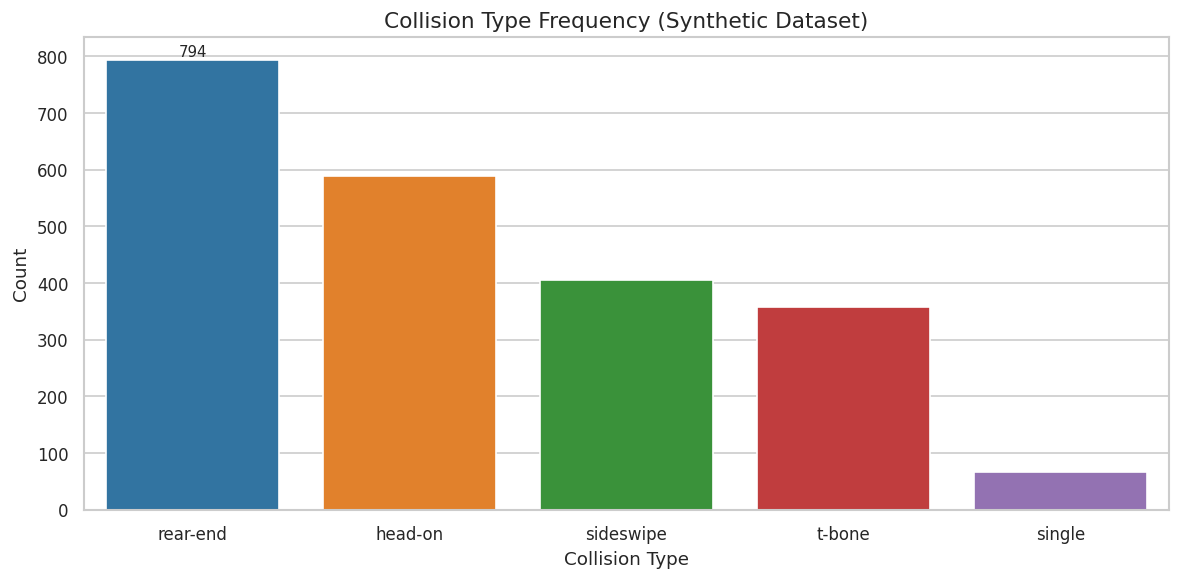

In [24]:
# [EDA] Collision type frequency -- bar chart
if not labels_clean.empty and 'type' in labels_clean.columns:
    type_freq = labels_clean['type'].value_counts().reset_index()
    type_freq.columns = ['collision_type', 'count']

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(
        data=type_freq,
        x='collision_type', y='count',
        palette=[PALETTE['primary'], PALETTE['secondary'], PALETTE['tertiary'],
                 PALETTE['quaternary'], PALETTE['quinary'], PALETTE['senary']],
        ax=ax
    )
    ax.set_title('Collision Type Frequency (Synthetic Dataset)', fontsize=13)
    ax.set_xlabel('Collision Type', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.bar_label(ax.containers[0], fontsize=9)
    plt.tight_layout()
    plt.show()

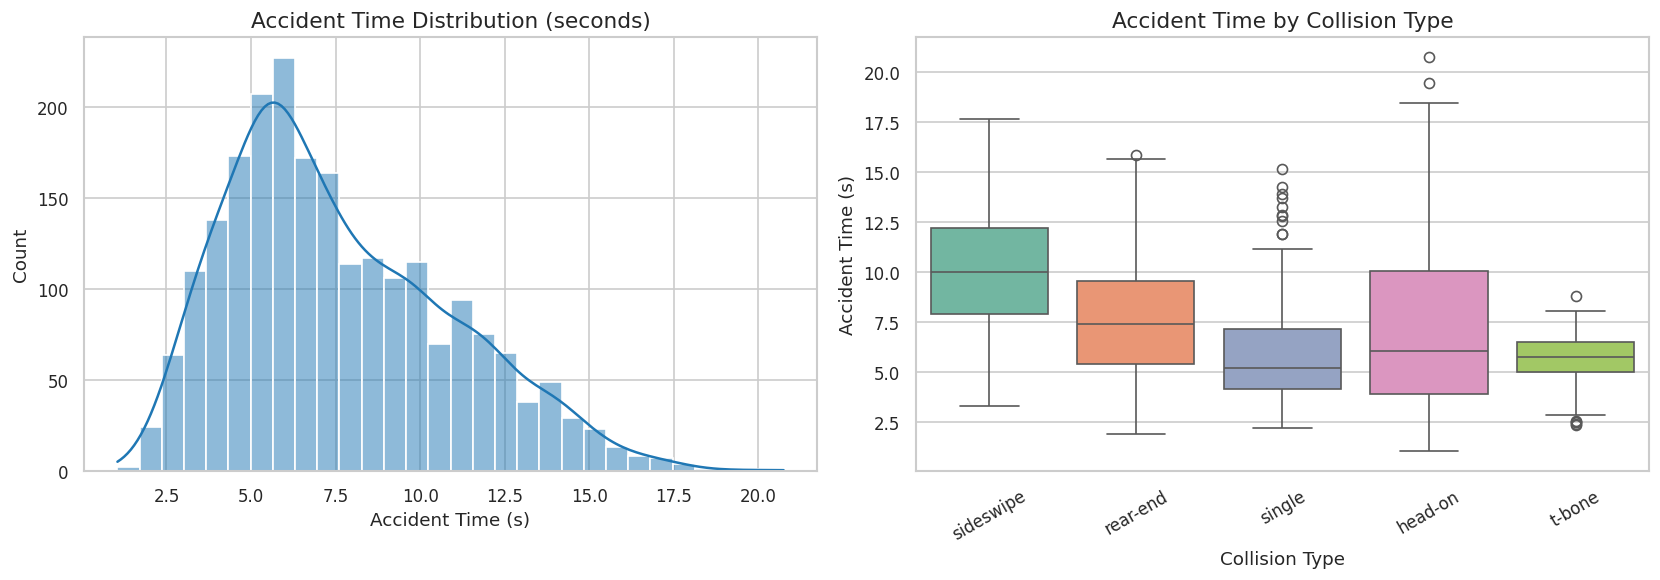

In [25]:
# [EDA] Accident time distribution -- histogram with KDE
if not labels_clean.empty and 'accident_time' in labels_clean.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram
    sns.histplot(
        labels_clean['accident_time'],
        bins=30, kde=True,
        color=PALETTE['primary'],
        ax=axes[0]
    )
    axes[0].set_title('Accident Time Distribution (seconds)', fontsize=13)
    axes[0].set_xlabel('Accident Time (s)', fontsize=11)
    axes[0].set_ylabel('Count', fontsize=11)

    # Box plot by collision type
    if 'type' in labels_clean.columns:
        sns.boxplot(
            data=labels_clean,
            x='type', y='accident_time',
            palette='Set2',
            ax=axes[1]
        )
        axes[1].set_title('Accident Time by Collision Type', fontsize=13)
        axes[1].set_xlabel('Collision Type', fontsize=11)
        axes[1].set_ylabel('Accident Time (s)', fontsize=11)
        axes[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()

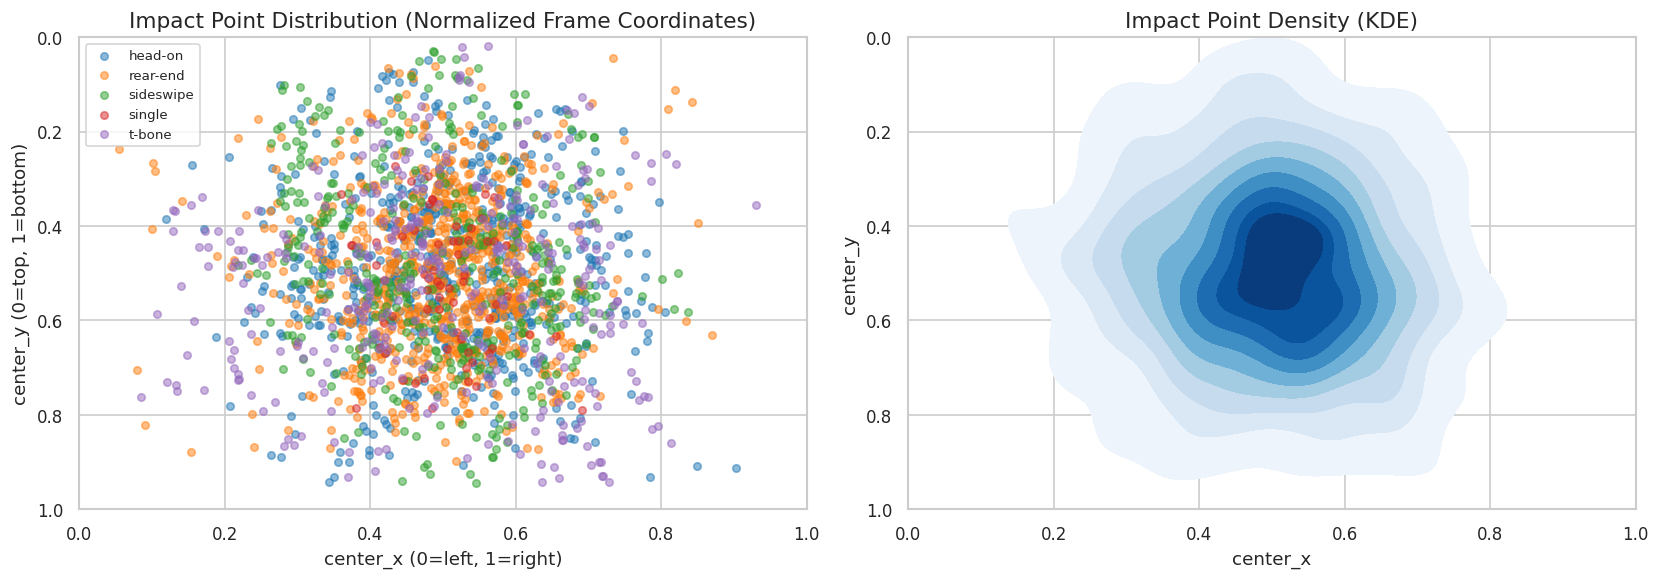

In [26]:
# [EDA] Spatial distribution of impact points -- 2D scatter and KDE
if not labels_clean.empty and all(c in labels_clean.columns for c in ['center_x', 'center_y']):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 2D scatter colored by type
    if 'type' in labels_clean.columns:
        for t_idx, (t_name, group) in enumerate(labels_clean.groupby('type')):
            axes[0].scatter(
                group['center_x'], group['center_y'],
                label=t_name, alpha=0.5, s=20,
                color=list(PALETTE.values())[t_idx % len(PALETTE)]
            )
        axes[0].legend(fontsize=8)
    else:
        axes[0].scatter(
            labels_clean['center_x'], labels_clean['center_y'],
            alpha=0.4, s=15, color=PALETTE['primary']
        )

    axes[0].set_title('Impact Point Distribution (Normalized Frame Coordinates)', fontsize=13)
    axes[0].set_xlabel('center_x (0=left, 1=right)', fontsize=11)
    axes[0].set_ylabel('center_y (0=top, 1=bottom)', fontsize=11)
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1)
    axes[0].invert_yaxis()  # match image coordinate convention

    # KDE heatmap
    sns.kdeplot(
        data=labels_clean,
        x='center_x', y='center_y',
        fill=True, cmap='Blues',
        ax=axes[1]
    )
    axes[1].set_title('Impact Point Density (KDE)', fontsize=13)
    axes[1].set_xlabel('center_x', fontsize=11)
    axes[1].set_ylabel('center_y', fontsize=11)
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()

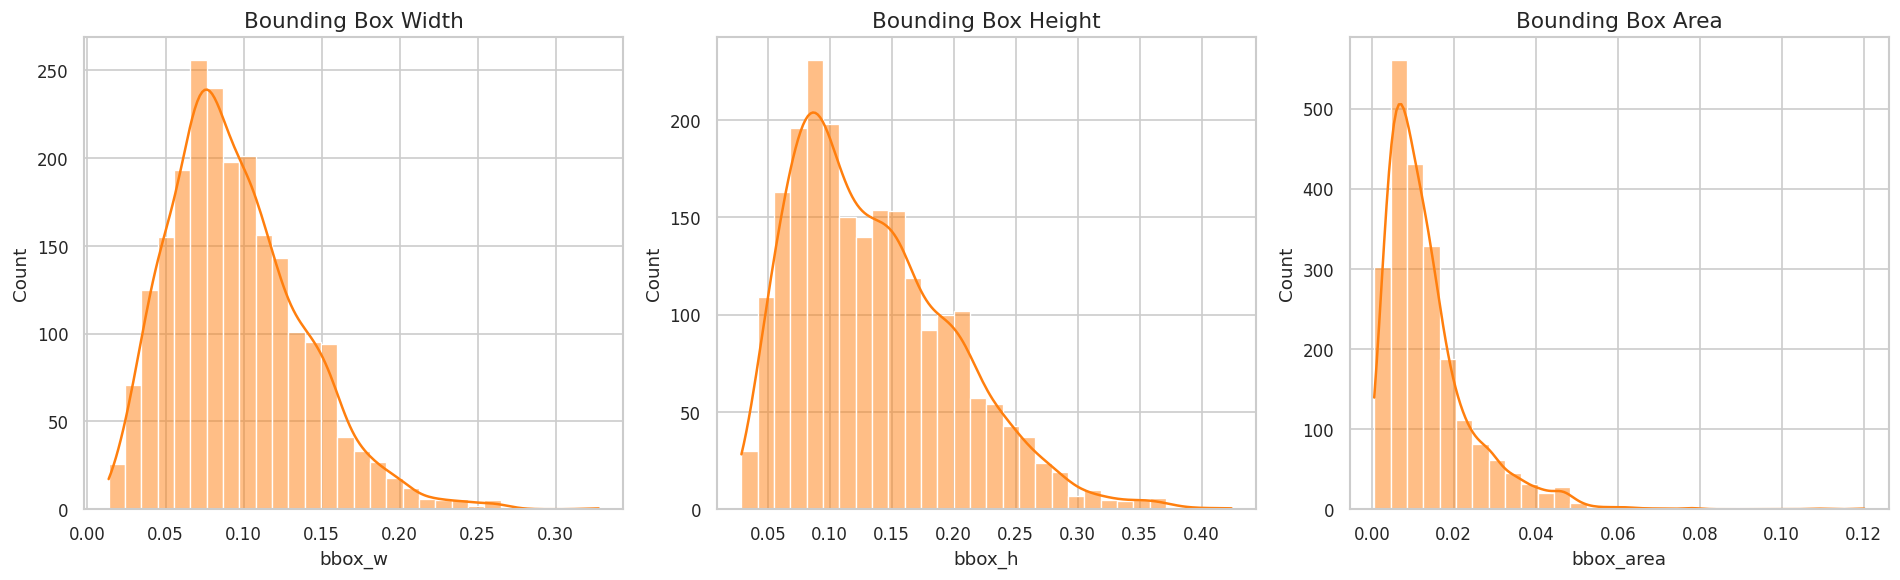

In [27]:
# [EDA] Bounding box size distribution -- box width and height
if not labels_clean.empty and all(c in labels_clean.columns for c in ['x1', 'y1', 'x2', 'y2']):
    labels_clean['bbox_w'] = labels_clean['x2'] - labels_clean['x1']
    labels_clean['bbox_h'] = labels_clean['y2'] - labels_clean['y1']
    labels_clean['bbox_area'] = labels_clean['bbox_w'] * labels_clean['bbox_h']

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for ax, col, title in zip(
        axes,
        ['bbox_w', 'bbox_h', 'bbox_area'],
        ['Bounding Box Width', 'Bounding Box Height', 'Bounding Box Area']
    ):
        sns.histplot(labels_clean[col], bins=30, kde=True, color=PALETTE['secondary'], ax=ax)
        ax.set_title(title, fontsize=13)
        ax.set_xlabel(col, fontsize=11)
        ax.set_ylabel('Count', fontsize=11)

    plt.tight_layout()
    plt.show()

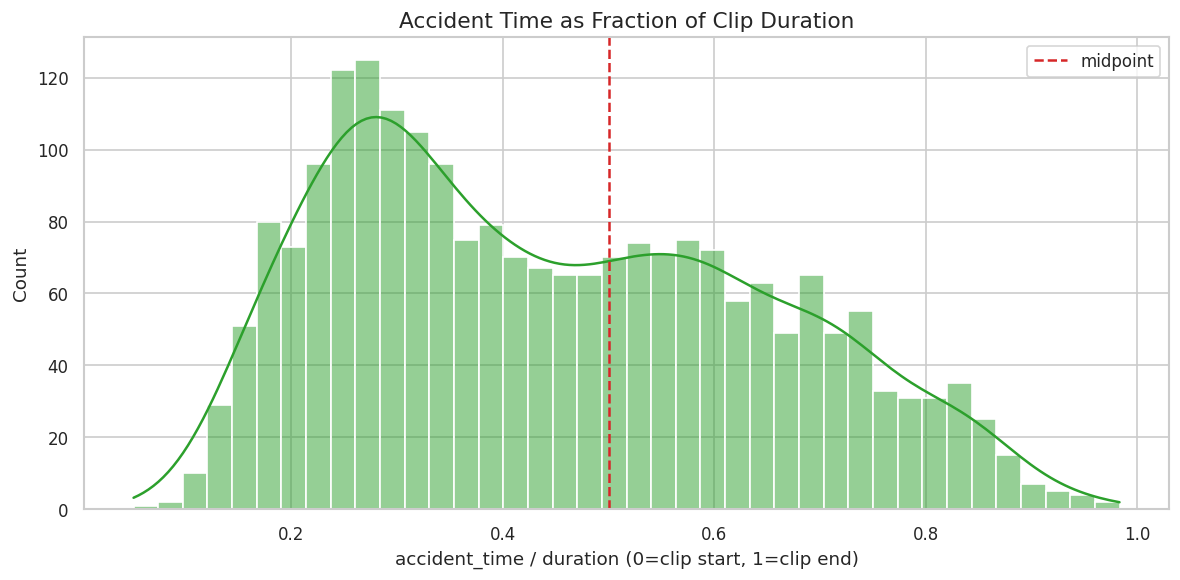

In [28]:
# [EDA] Accident time as fraction of clip duration -- relative temporal position
if not labels_clean.empty and all(c in labels_clean.columns for c in ['accident_time', 'duration']):
    labels_clean['time_fraction'] = labels_clean['accident_time'] / labels_clean['duration']

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.histplot(labels_clean['time_fraction'], bins=40, kde=True, color=PALETTE['tertiary'], ax=ax)
    ax.set_title('Accident Time as Fraction of Clip Duration', fontsize=13)
    ax.set_xlabel('accident_time / duration (0=clip start, 1=clip end)', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.axvline(0.5, color=PALETTE['quaternary'], linestyle='--', label='midpoint')
    ax.legend()
    plt.tight_layout()
    plt.show()

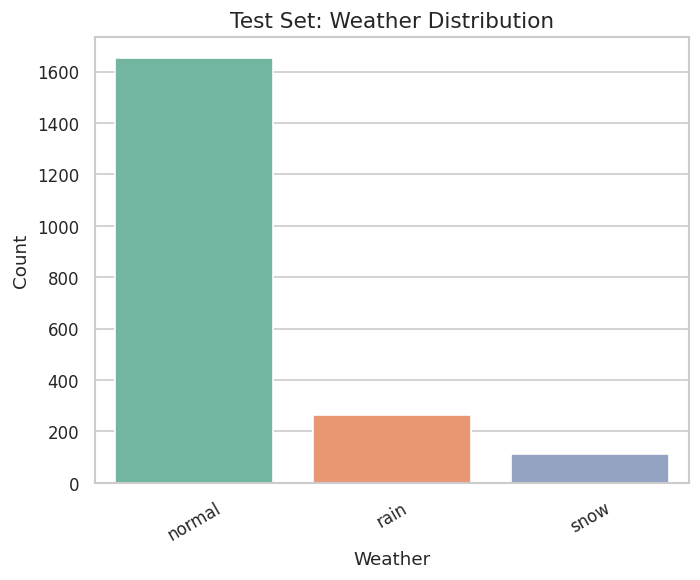

In [29]:
# [EDA] Scene condition distributions from real test metadata
SCENE_TAG_COLS = ['lighting', 'weather', 'layout']  # adjust to actual column names

if not test_df.empty:
    present_tags = [c for c in SCENE_TAG_COLS if c in test_df.columns]

    if present_tags:
        fig, axes = plt.subplots(1, len(present_tags), figsize=(6 * len(present_tags), 5))
        if len(present_tags) == 1:
            axes = [axes]

        for ax, col in zip(axes, present_tags):
            tag_freq = test_df[col].value_counts().reset_index()
            tag_freq.columns = [col, 'count']
            sns.barplot(data=tag_freq, x=col, y='count', palette='Set2', ax=ax)
            ax.set_title(f'Test Set: {col.title()} Distribution', fontsize=13)
            ax.set_xlabel(col.title(), fontsize=11)
            ax.set_ylabel('Count', fontsize=11)
            ax.tick_params(axis='x', rotation=30)

        plt.tight_layout()
        plt.show()
    else:
        print('[STATUS] Scene tag columns not found -- column names may differ')
else:
    print('[STATUS] test_df empty -- skipping scene tag plots')

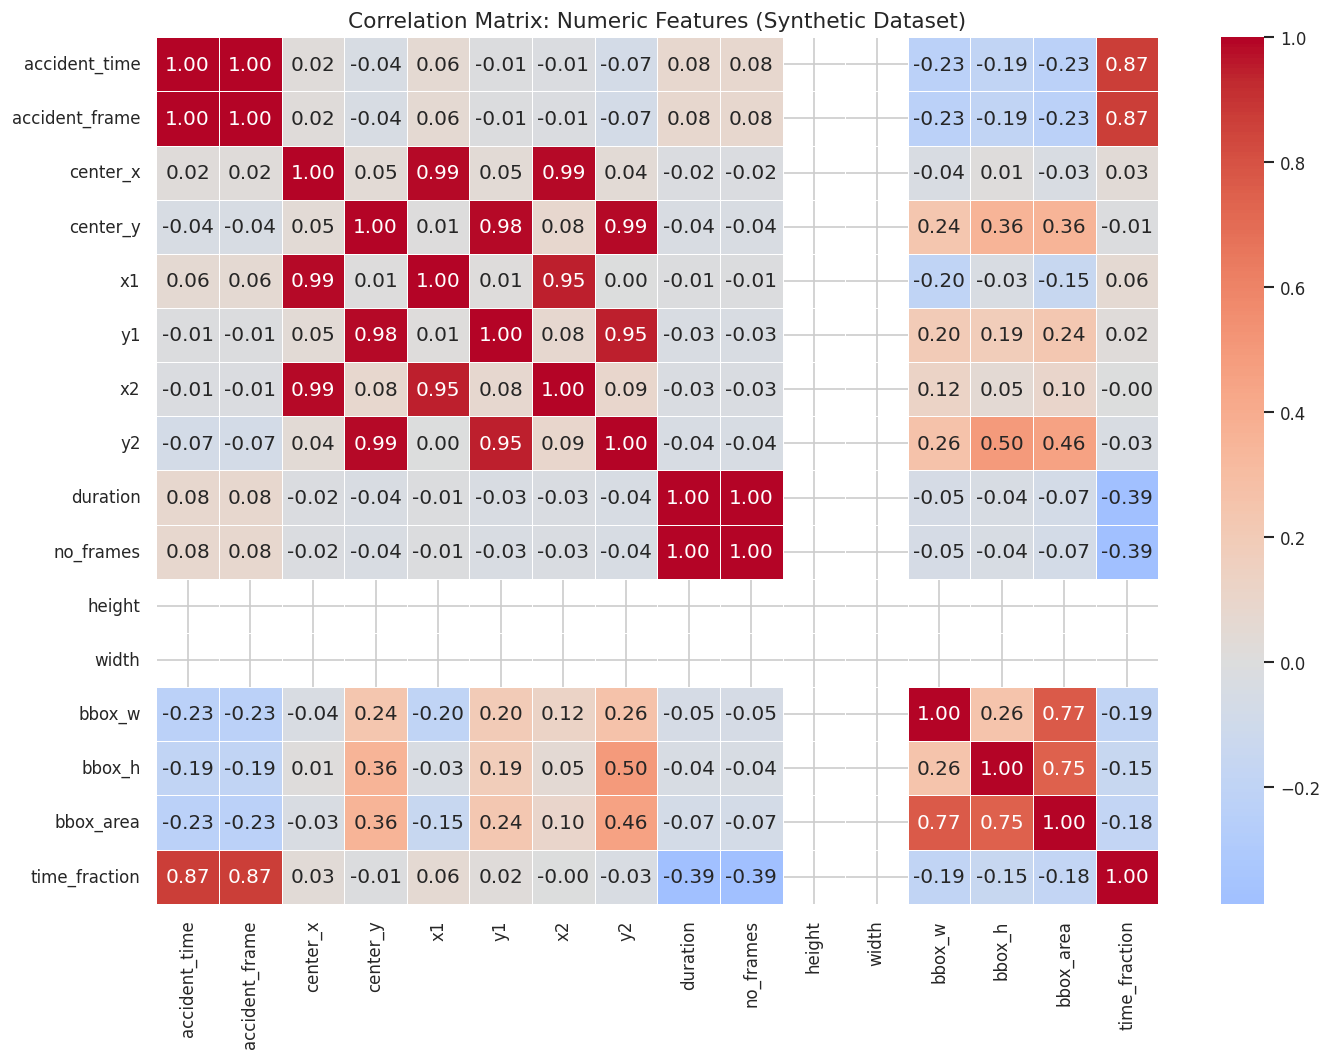

In [30]:
# [EDA] Correlation matrix across numeric features
numeric_cols = ['accident_time', 'accident_frame', 'center_x', 'center_y',
                'x1', 'y1', 'x2', 'y2', 'duration', 'no_frames',
                'height', 'width', 'bbox_w', 'bbox_h', 'bbox_area', 'time_fraction']

if not labels_clean.empty:
    present_numeric = [c for c in numeric_cols if c in labels_clean.columns]
    corr_matrix = labels_clean[present_numeric].corr()

    fig, ax = plt.subplots(figsize=(12, 9))
    sns.heatmap(
        corr_matrix,
        annot=True, fmt='.2f',
        cmap='coolwarm', center=0,
        linewidths=0.5,
        ax=ax
    )
    ax.set_title('Correlation Matrix: Numeric Features (Synthetic Dataset)', fontsize=13)
    plt.tight_layout()
    plt.show()

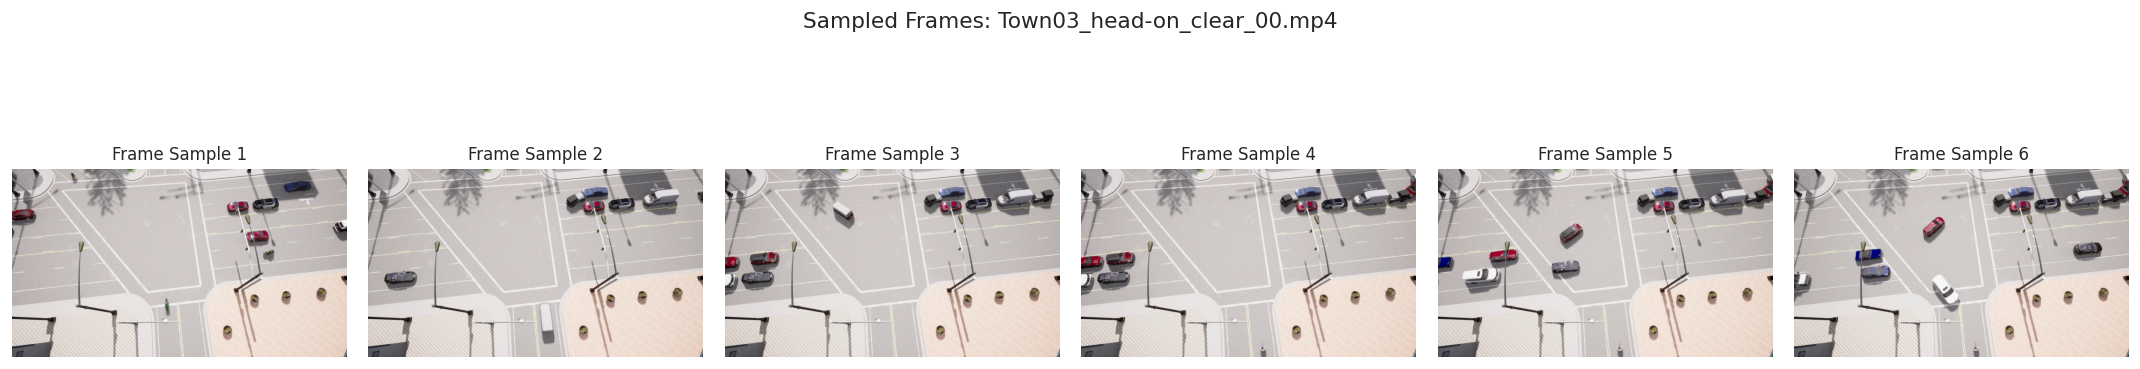

In [31]:
# [EDA] Sample frame extraction from a synthetic video for visual inspection
def sample_frames(video_path: pathlib.Path, n_frames: int = 6) -> list:
    """Extract n_frames evenly spaced frames from a video. Returns list of BGR arrays."""
    cap = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = np.linspace(0, total - 1, n_frames, dtype=int)
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()
    return frames

# [EDA] Display sampled frames from first available synthetic video
if synthetic_videos:
    sampled = sample_frames(synthetic_videos[0], n_frames=6)
    if sampled:
        fig, axes = plt.subplots(1, len(sampled), figsize=(18, 4))
        for i, (ax, frame) in enumerate(zip(axes, sampled)):
            ax.imshow(frame)
            ax.set_title(f'Frame Sample {i+1}', fontsize=10)
            ax.axis('off')
        fig.suptitle(f'Sampled Frames: {synthetic_videos[0].name}', fontsize=13)
        plt.tight_layout()
        plt.show()
else:
    print('[STATUS] No synthetic videos found for frame sampling')

---
## 5. Feature Engineering

This section defines the per-video feature extractors used by the inference pipeline. Three feature families are computed: (1) frame-difference time-series for temporal anomaly scoring, (2) optical-flow magnitude maps for spatial localization, and (3) a set of CLIP-compatible frame representations for collision-type classification.

In [32]:
# [FEATURE] Frame-difference series -- captures sharp intensity changes indicating collision

def compute_frame_diff_series(video_path: pathlib.Path,
                               resize_w: int = 320,
                               resize_h: int = 180) -> np.ndarray:
    """
    Compute mean absolute frame difference per consecutive pair.
    Returns 1D array of length (n_frames - 1).
    """
    cap = cv2.VideoCapture(str(video_path))
    diffs = []
    prev_gray = None

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        # Resize for computational efficiency
        frame_small = cv2.resize(frame, (resize_w, resize_h))
        gray = cv2.cvtColor(frame_small, cv2.COLOR_BGR2GRAY).astype(np.float32)

        if prev_gray is not None:
            diff = np.mean(np.abs(gray - prev_gray))
            diffs.append(diff)
        prev_gray = gray

    cap.release()
    return np.array(diffs, dtype=np.float32)

print('[STATUS] compute_frame_diff_series defined')

[STATUS] compute_frame_diff_series defined


In [33]:
# [FEATURE] Optical-flow magnitude map -- spatial localization of motion anomaly

def compute_flow_magnitude_map(video_path: pathlib.Path,
                                resize_w: int = 320,
                                resize_h: int = 180,
                                n_frames_context: int = 30,
                                center_frame: int = None,
                                flow_percentile: float = 90.0) -> np.ndarray:
    """
    Compute cumulative Farneback optical-flow magnitude map over a window of frames
    centered on center_frame. Applies percentile thresholding to suppress background
    motion before returning the map.
    Returns a 2D array of shape (resize_h, resize_w).
    """
    cap = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Center the flow window on center_frame if provided, else fall back to N/3
    if center_frame is not None:
        half_window = n_frames_context // 2
        start_frame = max(0, center_frame - half_window)
    else:
        start_frame = max(0, total // 3)
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    mag_accum = np.zeros((resize_h, resize_w), dtype=np.float32)
    prev_gray = None
    count = 0

    while count < n_frames_context:
        ret, frame = cap.read()
        if not ret:
            break
        frame_small = cv2.resize(frame, (resize_w, resize_h))
        gray = cv2.cvtColor(frame_small, cv2.COLOR_BGR2GRAY)

        if prev_gray is not None:
            # Farneback dense optical flow
            flow = cv2.calcOpticalFlowFarneback(
                prev_gray, gray,
                None,
                pyr_scale=0.5, levels=3, winsize=15,
                iterations=3, poly_n=5, poly_sigma=1.2,
                flags=0
            )
            mag, _ = cv2.cartToPolar(flow[..., 0], flow[..., 1])
            mag_accum += mag
        prev_gray = gray
        count += 1

    cap.release()

    # Percentile thresholding: zero out low-magnitude regions to suppress background motion
    if mag_accum.max() > 0:
        thresh = np.percentile(mag_accum, flow_percentile)
        mag_accum[mag_accum < thresh] = 0.0

    return mag_accum

print('[STATUS] compute_flow_magnitude_map defined')

[STATUS] compute_flow_magnitude_map defined


In [34]:
# [FEATURE] Temporal anomaly score -- smoothed z-score of frame-difference series

def score_temporal_anomaly(diff_series: np.ndarray,
                            smooth_window: int = 5) -> np.ndarray:
    """
    Apply rolling mean smoothing then z-score normalization.
    Returns anomaly score array aligned to diff_series length.
    """
    series = pd.Series(diff_series)
    smoothed = series.rolling(window=smooth_window, min_periods=1, center=True).mean().values
    mu    = smoothed.mean()
    sigma = smoothed.std() + 1e-8  # epsilon prevents division by zero
    z_scores = (smoothed - mu) / sigma
    return z_scores

print('[STATUS] score_temporal_anomaly defined')

[STATUS] score_temporal_anomaly defined


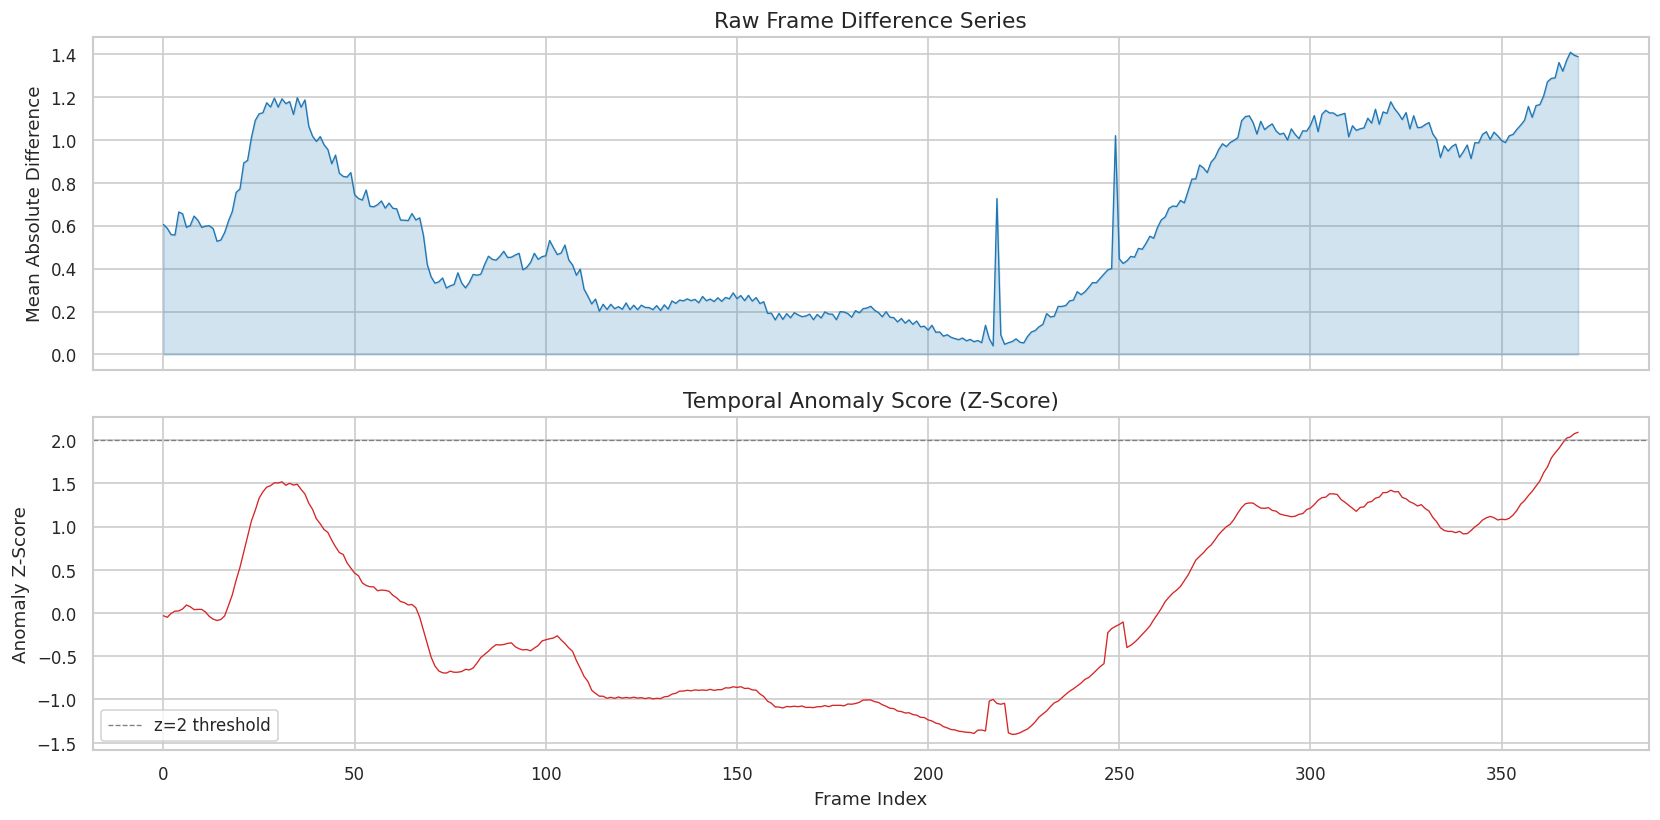

In [35]:
# [FEATURE] Visualize frame difference and anomaly score for a synthetic sample
if synthetic_videos:
    sample_path = synthetic_videos[0]
    diff_series = compute_frame_diff_series(sample_path)
    anomaly     = score_temporal_anomaly(diff_series)

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    axes[0].plot(diff_series, color=PALETTE['primary'], linewidth=0.8)
    axes[0].set_title('Raw Frame Difference Series', fontsize=13)
    axes[0].set_ylabel('Mean Absolute Difference', fontsize=11)
    axes[0].fill_between(range(len(diff_series)), 0, diff_series,
                         alpha=0.2, color=PALETTE['primary'])

    axes[1].plot(anomaly, color=PALETTE['quaternary'], linewidth=0.8)
    axes[1].axhline(2.0, linestyle='--', color='grey', linewidth=0.8, label='z=2 threshold')
    axes[1].set_title('Temporal Anomaly Score (Z-Score)', fontsize=13)
    axes[1].set_xlabel('Frame Index', fontsize=11)
    axes[1].set_ylabel('Anomaly Z-Score', fontsize=11)
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print('[STATUS] No synthetic videos -- skipping frame diff visualization')

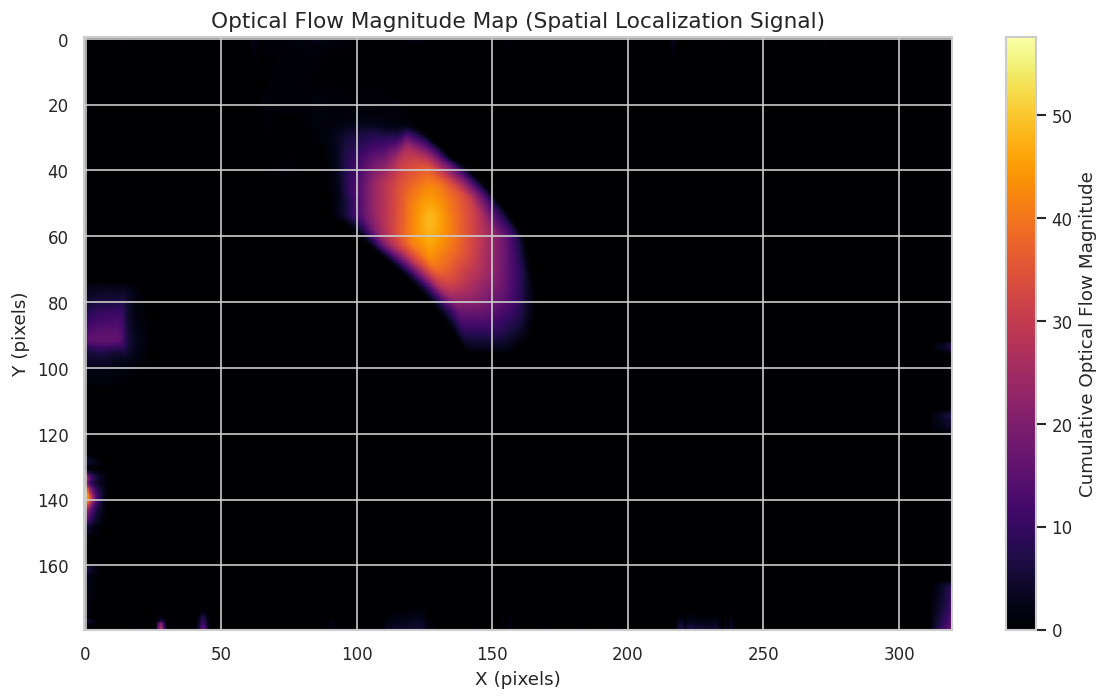

In [36]:
# [FEATURE] Visualize optical-flow magnitude map for a synthetic sample
if synthetic_videos:
    flow_map = compute_flow_magnitude_map(synthetic_videos[0])

    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(flow_map, cmap='inferno', aspect='auto')
    plt.colorbar(im, ax=ax, label='Cumulative Optical Flow Magnitude')
    ax.set_title('Optical Flow Magnitude Map (Spatial Localization Signal)', fontsize=13)
    ax.set_xlabel('X (pixels)', fontsize=11)
    ax.set_ylabel('Y (pixels)', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print('[STATUS] No synthetic videos -- skipping flow map visualization')

In [37]:
# [FEATURE] CLIP text prompt templates for each collision type
# These prompts are used for zero-shot similarity scoring
# Competition types: head-on, rear-end, sideswipe, single, t-bone

COLLISION_PROMPTS = {
    'rear-end'    : [
        'a car colliding into the back of another car',
        'rear-end collision between two vehicles on a road',
        'vehicle hitting the back of a stationary car from behind',
        'one car rear-ending another car at a traffic light',
        'a vehicle crashing into the tail of the car ahead',
    ],
    't-bone'      : [
        'a car hitting the side of another car at an intersection',
        't-bone collision at a crossroads between two vehicles',
        'side impact crash where one car strikes another perpendicularly',
        'a vehicle running a red light and hitting the side of crossing traffic',
        'perpendicular collision between two cars at a junction',
    ],
    'head-on'     : [
        'two cars colliding head-on from opposite directions',
        'frontal collision between two vehicles on a road',
        'head-on crash between two cars driving toward each other',
        'two vehicles smashing front-to-front on a highway',
        'a car crossing the center line and hitting an oncoming vehicle head-on',
    ],
    'sideswipe'   : [
        'two vehicles scraping alongside each other while driving',
        'sideswipe collision between cars changing lanes',
        'glancing blow between two cars moving in the same direction',
        'a car drifting into the adjacent lane and scraping another vehicle',
        'two vehicles brushing sides while traveling parallel on a road',
    ],
    'single'      : [
        'a single car crashing into a wall or barrier',
        'one vehicle running off the road and hitting an obstacle',
        'a car losing control and crashing into a pole or guardrail',
        'a single vehicle spinning out and hitting a roadside object',
        'one car veering off the road and crashing without involving another vehicle',
    ],
}

# [STATUS] Prompt inventory
prompt_summary = pd.DataFrame([
    {'collision_type': k, 'n_prompts': len(v)}
    for k, v in COLLISION_PROMPTS.items()
])
display(prompt_summary)
print('[STATUS] Collision prompt templates defined')

,collision_type,n_prompts
0,rear-end,5
1,t-bone,5
2,head-on,5
3,sideswipe,5
4,single,5


[STATUS] Collision prompt templates defined


---
## 6. Modeling

This section implements the three-component zero-shot inference pipeline. Component 1 (temporal): peak detection on the z-scored frame-difference series. Component 2 (spatial): weighted centroid of the optical-flow magnitude map. Component 3 (classification): cosine similarity between CLIP image embeddings of peak-region frames and CLIP text embeddings of collision-type prompts.

In [38]:
# [MODEL] Load CLIP model and preprocessing transform
if CLIP_AVAILABLE:
    clip_model, clip_preprocess = clip.load('ViT-L/14', device=DEVICE)
    clip_model.eval()

    # Pre-encode all collision-type text prompts to avoid repeated computation
    TYPE_TEXT_FEATURES = {}
    with torch.no_grad():
        for ctype, prompts in COLLISION_PROMPTS.items():
            tokens   = clip.tokenize(prompts).to(DEVICE)
            features = clip_model.encode_text(tokens)     # shape: (n_prompts, 768)
            features = features / features.norm(dim=-1, keepdim=True)  # L2 normalize
            TYPE_TEXT_FEATURES[ctype] = features.mean(dim=0)  # mean-pool across prompts

    print(f'[SUCCESS] CLIP ViT-L/14 loaded | text features for {len(TYPE_TEXT_FEATURES)} types pre-computed')
else:
    print('[STATUS] CLIP unavailable -- classification will use heuristic fallback')

100%|███████████████████████████████████████| 890M/890M [00:14<00:00, 63.4MiB/s]


[SUCCESS] CLIP ViT-L/14 loaded | text features for 5 types pre-computed


In [39]:
# [MODEL] Temporal prediction -- peak detection in anomaly score series

def predict_accident_time(video_path: pathlib.Path,
                           smooth_window: int = 5,
                           z_threshold: float = 1.5) -> float:
    """
    Predict accident time in seconds via peak detection on frame-difference z-scores.
    Among all frames exceeding z_threshold, selects the one with the highest z-score
    (the strongest anomaly). Falls back to global argmax if no frame exceeds threshold.
    """
    cap = cv2.VideoCapture(str(video_path))
    fps       = cap.get(cv2.CAP_PROP_FPS)
    n_frames  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    if fps <= 0 or n_frames == 0:
        return 0.0

    # Compute and smooth frame differences
    diff_series = compute_frame_diff_series(video_path)
    if len(diff_series) == 0:
        return n_frames / fps / 2.0  # midpoint fallback

    anomaly = score_temporal_anomaly(diff_series, smooth_window)

    # Among candidates exceeding threshold, pick the strongest peak
    candidates = np.where(anomaly > z_threshold)[0]
    if len(candidates) == 0:
        # Fallback: global argmax of anomaly series
        peak_frame = int(np.argmax(anomaly))
    else:
        # Select the candidate with the highest anomaly score
        peak_frame = int(candidates[np.argmax(anomaly[candidates])])

    return round(peak_frame / fps, 4)

print('[STATUS] predict_accident_time defined')

[STATUS] predict_accident_time defined


In [40]:
# [MODEL] Spatial prediction -- weighted centroid of optical-flow magnitude map

def predict_impact_location(video_path: pathlib.Path,
                              accident_time: float = None,
                              n_frames_context: int = 30) -> tuple:
    """
    Predict normalized (center_x, center_y) impact location.
    Uses the weighted centroid of the cumulative optical-flow magnitude map,
    centered on the detected accident time for spatial precision.
    Returns (cx, cy) both in [0, 1].
    """
    RESIZE_W, RESIZE_H = 320, 180

    # Convert accident_time to frame index for centering the flow window
    center_frame = None
    if accident_time is not None:
        cap_tmp = cv2.VideoCapture(str(video_path))
        fps = cap_tmp.get(cv2.CAP_PROP_FPS)
        cap_tmp.release()
        if fps > 0:
            center_frame = int(accident_time * fps)

    mag_map = compute_flow_magnitude_map(
        video_path,
        resize_w=RESIZE_W,
        resize_h=RESIZE_H,
        n_frames_context=n_frames_context,
        center_frame=center_frame,
    )

    total_mag = mag_map.sum()
    if total_mag < 1e-6:
        return 0.5, 0.5  # center fallback when no motion detected

    # Build coordinate grids
    ys, xs = np.mgrid[0:RESIZE_H, 0:RESIZE_W]

    # Weighted centroid computation
    cx = float((xs * mag_map).sum() / total_mag) / RESIZE_W
    cy = float((ys * mag_map).sum() / total_mag) / RESIZE_H

    return round(cx, 6), round(cy, 6)

print('[STATUS] predict_impact_location defined')

[STATUS] predict_impact_location defined


In [41]:
# [MODEL] Collision type classification via CLIP zero-shot similarity

def extract_frames_around_peak(video_path: pathlib.Path,
                                peak_time_s: float,
                                n_context_frames: int = 8,
                                fps: float = None) -> list:
    """
    Extract n_context_frames frames centered on peak_time_s.
    Returns list of PIL Images for CLIP preprocessing.
    """
    from PIL import Image as PILImage

    cap = cv2.VideoCapture(str(video_path))
    if fps is None:
        fps = cap.get(cv2.CAP_PROP_FPS)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    peak_frame = int(peak_time_s * fps)
    half       = n_context_frames // 2
    frame_idxs = list(range(
        max(0, peak_frame - half),
        min(total, peak_frame + half + 1)
    ))

    pil_frames = []
    for idx in frame_idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            pil_frames.append(PILImage.fromarray(rgb))

    cap.release()
    return pil_frames


def predict_collision_type(video_path: pathlib.Path,
                            peak_time_s: float) -> str:
    """
    Zero-shot collision type classification using CLIP.
    Returns the collision type string with highest mean cosine similarity.
    Falls back to 'rear-end' (most common) when CLIP is unavailable.
    """
    if not CLIP_AVAILABLE:
        return 'rear-end'

    pil_frames = extract_frames_around_peak(video_path, peak_time_s, n_context_frames=8)
    if not pil_frames:
        return 'rear-end'

    # Preprocess and encode frames
    with torch.no_grad():
        img_tensors = torch.stack([
            clip_preprocess(f) for f in pil_frames
        ]).to(DEVICE)
        img_features = clip_model.encode_image(img_tensors)       # (n_frames, 768)
        img_features = img_features / img_features.norm(dim=-1, keepdim=True)
        img_feature  = img_features.mean(dim=0)                   # mean pool across frames

    # Cosine similarity against each type's pre-computed text embedding
    scores = {}
    for ctype, text_feat in TYPE_TEXT_FEATURES.items():
        sim = (img_feature @ text_feat).item()
        scores[ctype] = sim

    return max(scores, key=scores.get)

print('[STATUS] predict_collision_type defined')

[STATUS] predict_collision_type defined


In [42]:
# [MODEL] Full single-video inference function -- combines all three predictions

def run_inference(video_path: pathlib.Path) -> dict:
    """
    Run full pipeline on one video.
    Returns dict with keys: path, accident_time, center_x, center_y, type.
    """
    # Step 1: Temporal prediction
    acc_time = predict_accident_time(video_path)

    # Step 2: Spatial prediction (centered on detected accident time)
    cx, cy = predict_impact_location(video_path, accident_time=acc_time)

    # Step 3: Classification
    col_type = predict_collision_type(video_path, acc_time)

    return {
        'path'          : str(video_path),
        'accident_time' : acc_time,
        'center_x'      : cx,
        'center_y'      : cy,
        'type'          : col_type,
    }

print('[STATUS] run_inference defined')

[STATUS] run_inference defined


In [43]:
# [MODEL] Calibration run on synthetic validation sample
# Runs inference on a small synthetic subset to verify pipeline correctness

CALIBRATION_N = min(10, len(synthetic_videos))
calibration_results = []

for i, vp in enumerate(synthetic_videos[:CALIBRATION_N]):
    result = run_inference(vp)
    calibration_results.append(result)
    print(f'[STATUS] Calibration {i+1}/{CALIBRATION_N}: {vp.name} | '
          f't={result["accident_time"]:.2f}s | '
          f'({result["center_x"]:.3f}, {result["center_y"]:.3f}) | '
          f'{result["type"]}')

calibration_df = pd.DataFrame(calibration_results)
display(calibration_df)

[STATUS] Calibration 1/10: Town03_head-on_clear_00.mp4 | t=18.50s | (0.468, 0.496) | t-bone
[STATUS] Calibration 2/10: Town03_head-on_clear_01.mp4 | t=0.00s | (0.238, 0.707) | t-bone
[STATUS] Calibration 3/10: Town03_head-on_clear_03.mp4 | t=0.85s | (0.479, 0.650) | t-bone
[STATUS] Calibration 4/10: Town03_head-on_clear_04.mp4 | t=0.30s | (0.513, 0.603) | t-bone
[STATUS] Calibration 5/10: Town03_head-on_clear_05.mp4 | t=1.80s | (0.598, 0.720) | t-bone
[STATUS] Calibration 6/10: Town03_head-on_clear_06.mp4 | t=2.25s | (0.816, 0.731) | t-bone
[STATUS] Calibration 7/10: Town03_head-on_clear_07.mp4 | t=2.65s | (0.732, 0.536) | t-bone
[STATUS] Calibration 8/10: Town03_head-on_clear_09.mp4 | t=1.35s | (0.410, 0.713) | t-bone
[STATUS] Calibration 9/10: Town03_head-on_clear_10.mp4 | t=0.00s | (0.495, 0.620) | t-bone
[STATUS] Calibration 10/10: Town03_head-on_clear_11.mp4 | t=19.65s | (0.481, 0.236) | t-bone


,path,accident_time,center_x,center_y,type
0,/kaggle/input/competitions/accident/sim_datase...,18.50,0.467562,0.495931,t-bone
1,/kaggle/input/competitions/accident/sim_datase...,0.00,0.237971,0.706616,t-bone
2,/kaggle/input/competitions/accident/sim_datase...,0.85,0.478593,0.650442,t-bone
3,/kaggle/input/competitions/accident/sim_datase...,0.30,0.513151,0.602921,t-bone
4,/kaggle/input/competitions/accident/sim_datase...,1.80,0.597826,0.720208,t-bone
5,/kaggle/input/competitions/accident/sim_datase...,2.25,0.815741,0.731496,t-bone
6,/kaggle/input/competitions/accident/sim_datase...,2.65,0.731818,0.536154,t-bone
7,/kaggle/input/competitions/accident/sim_datase...,1.35,0.409986,0.713369,t-bone
8,/kaggle/input/competitions/accident/sim_datase...,0.00,0.494670,0.619950,t-bone
9,/kaggle/input/competitions/accident/sim_datase...,19.65,0.481425,0.235542,t-bone


In [44]:
# [MODEL] Full test set inference -- process all real test videos
print(f'[STATUS] Starting inference on {len(real_videos)} real test videos...')

test_results = []
for i, vp in enumerate(real_videos):
    result = run_inference(vp)
    # Submission path format: videos/<filename>.mp4 (relative to BASE_DIR)
    result['path'] = 'videos/' + vp.name
    test_results.append(result)

    if (i + 1) % 10 == 0 or (i + 1) == len(real_videos):
        print(f'[STATUS] Processed {i+1}/{len(real_videos)} videos')

test_preds_df = pd.DataFrame(test_results)
print(f'[SUCCESS] Inference complete. Predictions shape: {test_preds_df.shape}')
display(test_preds_df.head())

[STATUS] Starting inference on 2027 real test videos...
[STATUS] Processed 10/2027 videos
[STATUS] Processed 20/2027 videos
[STATUS] Processed 30/2027 videos
[STATUS] Processed 40/2027 videos
[STATUS] Processed 50/2027 videos
[STATUS] Processed 60/2027 videos
[STATUS] Processed 70/2027 videos
[STATUS] Processed 80/2027 videos
[STATUS] Processed 90/2027 videos
[STATUS] Processed 100/2027 videos
[STATUS] Processed 110/2027 videos
[STATUS] Processed 120/2027 videos
[STATUS] Processed 130/2027 videos
[STATUS] Processed 140/2027 videos
[STATUS] Processed 150/2027 videos
[STATUS] Processed 160/2027 videos
[STATUS] Processed 170/2027 videos
[STATUS] Processed 180/2027 videos
[STATUS] Processed 190/2027 videos
[STATUS] Processed 200/2027 videos
[STATUS] Processed 210/2027 videos
[STATUS] Processed 220/2027 videos
[STATUS] Processed 230/2027 videos
[STATUS] Processed 240/2027 videos
[STATUS] Processed 250/2027 videos
[STATUS] Processed 260/2027 videos
[STATUS] Processed 270/2027 videos
[STATUS]

,path,accident_time,center_x,center_y,type
0,videos/-2UPLUV7JLg_00.mp4,19.6656,0.199689,0.659391,single
1,videos/-6SQSDj8cYU_00.mp4,4.8734,0.256331,0.560759,t-bone
2,videos/-7-vQ4obVwQ_00.mp4,5.0000,0.447488,0.729669,t-bone
3,videos/-9oifpjUxxM_00.mp4,11.7746,0.611559,0.818066,single
4,videos/-AztVDZ6cEE_00.mp4,3.1940,0.145108,0.636375,t-bone


In [45]:
# [MODEL] Align predictions with sample submission path format
if not sample_sub.empty and not test_preds_df.empty:
    # Merge on path to ensure row order matches submission format
    submission_df = sample_sub[['path']].merge(
        test_preds_df[['path', 'accident_time', 'center_x', 'center_y', 'type']],
        on='path', how='left'
    )

    # Fill any unmatched rows with defaults
    submission_df['accident_time'].fillna(10.0, inplace=True)
    submission_df['center_x'].fillna(0.5, inplace=True)
    submission_df['center_y'].fillna(0.5, inplace=True)
    submission_df['type'].fillna('rear-end', inplace=True)

    # [STATUS] Submission completeness check
    missing_preds = submission_df[['accident_time', 'center_x', 'center_y', 'type']].isnull().sum()
    display(missing_preds.rename('missing_count').to_frame())
else:
    # Construct submission directly from predictions when sample_sub unavailable
    submission_df = test_preds_df[['path', 'accident_time', 'center_x', 'center_y', 'type']].copy()

print(f'[STATUS] Submission rows: {len(submission_df)}')

[STATUS] Submission rows: 2027


In [46]:
# [MODEL] Save submission CSV to working directory
SUBMISSION_PATH = OUTPUT_DIR / 'submission.csv'
submission_df.to_csv(SUBMISSION_PATH, index=False)
print(f'[SUCCESS] Submission saved: {SUBMISSION_PATH}')
display(submission_df.head())

[SUCCESS] Submission saved: /kaggle/working/submission.csv


,path,accident_time,center_x,center_y,type
0,videos/-2UPLUV7JLg_00.mp4,19.6656,0.199689,0.659391,single
1,videos/-6SQSDj8cYU_00.mp4,4.8734,0.256331,0.560759,t-bone
2,videos/-7-vQ4obVwQ_00.mp4,5.0000,0.447488,0.729669,t-bone
3,videos/-9oifpjUxxM_00.mp4,11.7746,0.611559,0.818066,single
4,videos/-AztVDZ6cEE_00.mp4,3.1940,0.145108,0.636375,t-bone


---
## 7. Evaluation

This section implements the exact scoring functions specified by the competition, applies them to the calibration set (synthetic, with ground truth), and visualizes per-component score distributions. The harmonic mean of temporal, spatial, and classification scores is computed as the final leaderboard metric proxy.

In [47]:
# [EVAL] Temporal score -- Gaussian similarity between predicted and GT accident time

def temporal_score(pred_time: float, gt_time: float, sigma: float = 2.0) -> float:
    """
    Gaussian-style temporal similarity.
    sigma: standard deviation in seconds controlling penalty sharpness.
    Returns score in [0, 1].
    """
    return float(np.exp(-0.5 * ((pred_time - gt_time) / sigma) ** 2))


# [EVAL] Spatial score -- Gaussian similarity between predicted and GT impact location

def spatial_score(pred_x: float, pred_y: float,
                   gt_x: float,   gt_y: float,
                   sigma: float = 0.1) -> float:
    """
    Gaussian-style spatial similarity in normalized [0,1] coordinate space.
    sigma: standard deviation controlling spatial penalty.
    Returns score in [0, 1].
    """
    dist2 = (pred_x - gt_x) ** 2 + (pred_y - gt_y) ** 2
    return float(np.exp(-0.5 * dist2 / (sigma ** 2)))


# [EVAL] Classification score -- Top-1 binary accuracy

def classification_score(pred_type: str, gt_type: str) -> int:
    """Returns 1 if predicted type matches ground truth, else 0."""
    return int(pred_type.strip().lower() == gt_type.strip().lower())


# [EVAL] Final harmonic mean score

def harmonic_mean(t: float, s: float, c: float) -> float:
    """Harmonic mean of three scores in [0, 1]. Returns 0 if any component is 0."""
    if t <= 0 or s <= 0 or c <= 0:
        return 0.0
    return 3.0 / (1.0 / t + 1.0 / s + 1.0 / c)

print('[STATUS] Scoring functions defined')

[STATUS] Scoring functions defined


In [48]:
# [EVAL] Apply scores to calibration set where ground truth is available
if not calibration_df.empty and not labels_clean.empty and 'rgb_path' in labels_clean.columns:

    # Extract filename stem for join key (e.g., Town03_head-on_clear_00)
    calibration_df['video_stem'] = calibration_df['path'].apply(
        lambda p: pathlib.Path(p).stem
    )
    labels_clean['video_stem'] = labels_clean['rgb_path'].apply(
        lambda p: pathlib.Path(p).stem
    )

    eval_df = calibration_df.merge(
        labels_clean[['video_stem', 'accident_time', 'center_x', 'center_y', 'type']],
        on='video_stem', how='inner',
        suffixes=('_pred', '_gt')
    )

    if not eval_df.empty:
        # Compute per-video component scores
        eval_df['T'] = eval_df.apply(
            lambda r: temporal_score(r['accident_time_pred'], r['accident_time_gt']), axis=1)
        eval_df['S'] = eval_df.apply(
            lambda r: spatial_score(r['center_x_pred'], r['center_y_pred'],
                                     r['center_x_gt'],  r['center_y_gt']), axis=1)
        eval_df['C'] = eval_df.apply(
            lambda r: classification_score(r['type_pred'], r['type_gt']), axis=1)
        eval_df['H'] = eval_df.apply(
            lambda r: harmonic_mean(r['T'], r['S'], r['C']), axis=1)

        # [STATUS] Aggregate score summary
        score_summary = eval_df[['T', 'S', 'C', 'H']].mean().round(4).rename('mean_score').to_frame()
        display(score_summary)
        display(eval_df[['video_stem', 'T', 'S', 'C', 'H']].head(10))
    else:
        print('[STATUS] No matching video stems between calibration predictions and labels')
else:
    print('[STATUS] Skipping scoring -- calibration_df or labels_clean empty or missing rgb_path')

,mean_score
T,0.4382
S,0.1680
C,0.0000
H,0.0000


,video_stem,T,S,C,H
0,Town03_head-on_clear_00,5.057103e-13,4.552013e-04,0,0.0
1,Town03_head-on_clear_01,3.008180e-01,1.453237e-06,0,0.0
2,Town03_head-on_clear_03,7.962735e-01,3.153188e-07,0,0.0
3,Town03_head-on_clear_04,1.806399e-01,5.522179e-01,0,0.0
4,Town03_head-on_clear_05,5.460744e-01,1.227459e-05,0,0.0
5,Town03_head-on_clear_06,7.827045e-01,6.788545e-08,0,0.0
6,Town03_head-on_clear_07,6.368316e-01,4.044006e-04,0,0.0
7,Town03_head-on_clear_09,9.405881e-01,1.621512e-01,0,0.0
8,Town03_head-on_clear_10,1.978987e-01,9.642278e-01,0,0.0
9,Town03_head-on_clear_11,8.478439e-15,1.423830e-04,0,0.0


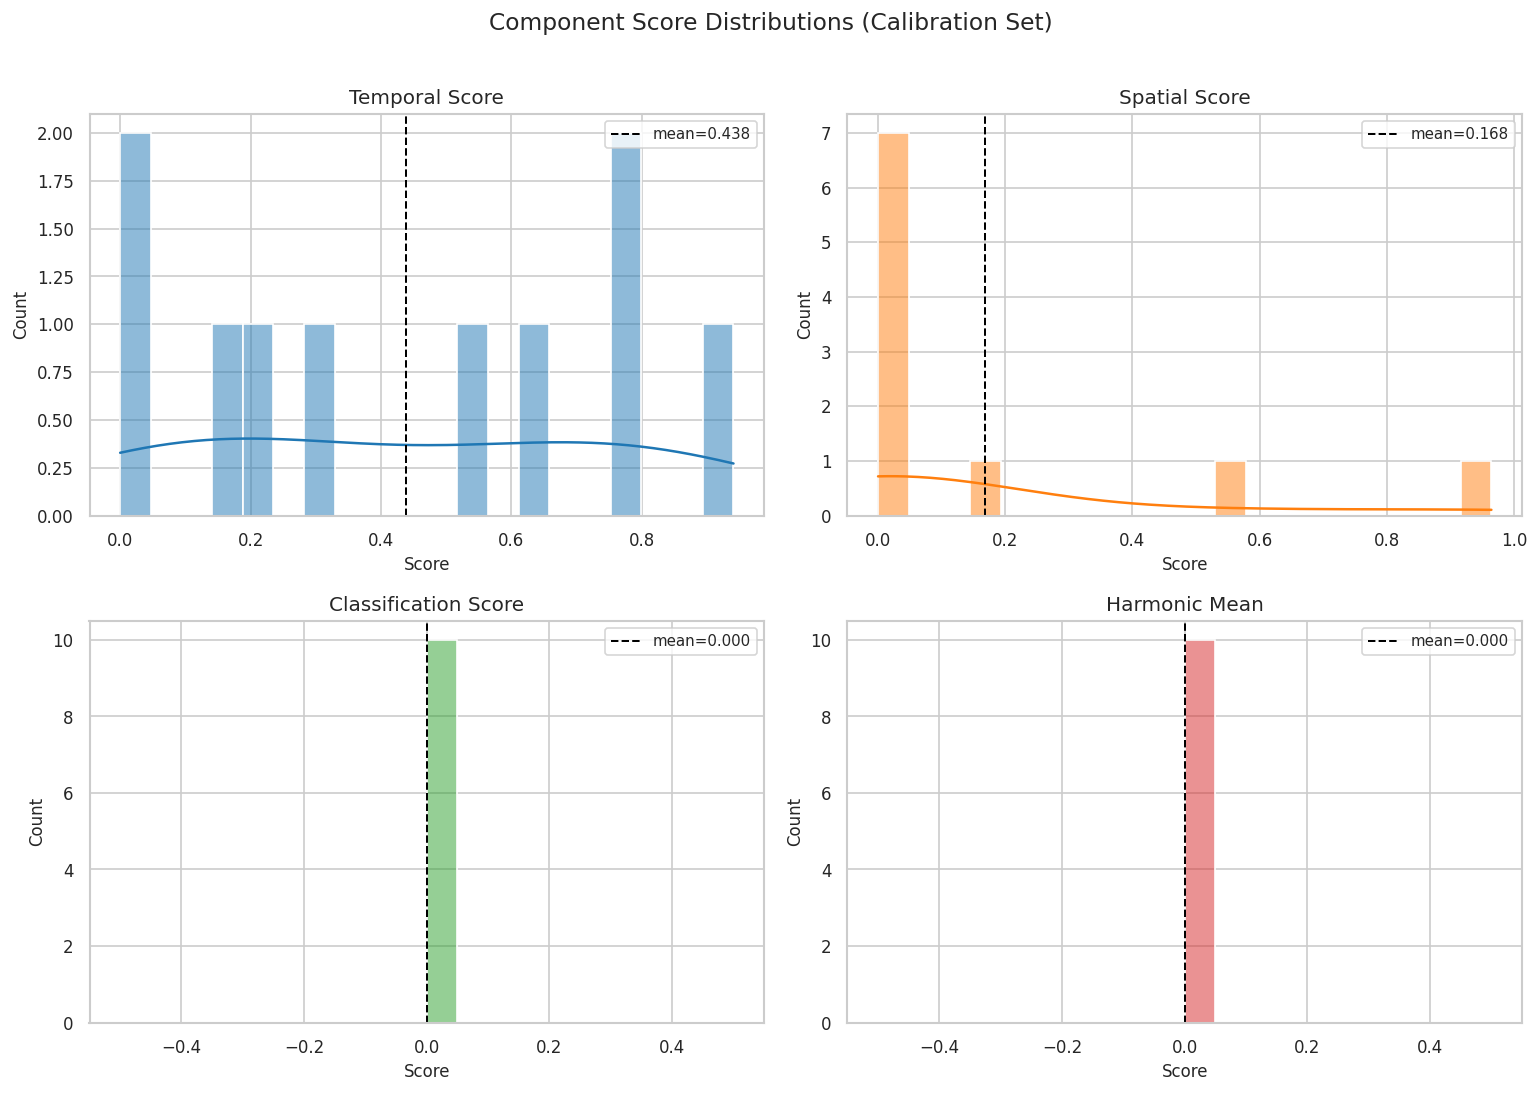

In [49]:
# [EVAL] Score distribution visualization
if 'eval_df' in dir() and not eval_df.empty and 'T' in eval_df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    axes = axes.flatten()

    score_cols  = ['T', 'S', 'C', 'H']
    score_names = ['Temporal Score', 'Spatial Score', 'Classification Score', 'Harmonic Mean']
    colors      = [PALETTE['primary'], PALETTE['secondary'], PALETTE['tertiary'], PALETTE['quaternary']]

    for ax, col, name, color in zip(axes, score_cols, score_names, colors):
        sns.histplot(eval_df[col], bins=20, kde=True, color=color, ax=ax)
        ax.axvline(eval_df[col].mean(), linestyle='--', color='black',
                   linewidth=1.2, label=f'mean={eval_df[col].mean():.3f}')
        ax.set_title(name, fontsize=12)
        ax.set_xlabel('Score', fontsize=10)
        ax.set_ylabel('Count', fontsize=10)
        ax.legend(fontsize=9)

    plt.suptitle('Component Score Distributions (Calibration Set)', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('[STATUS] eval_df not populated -- skipping score distribution plot')

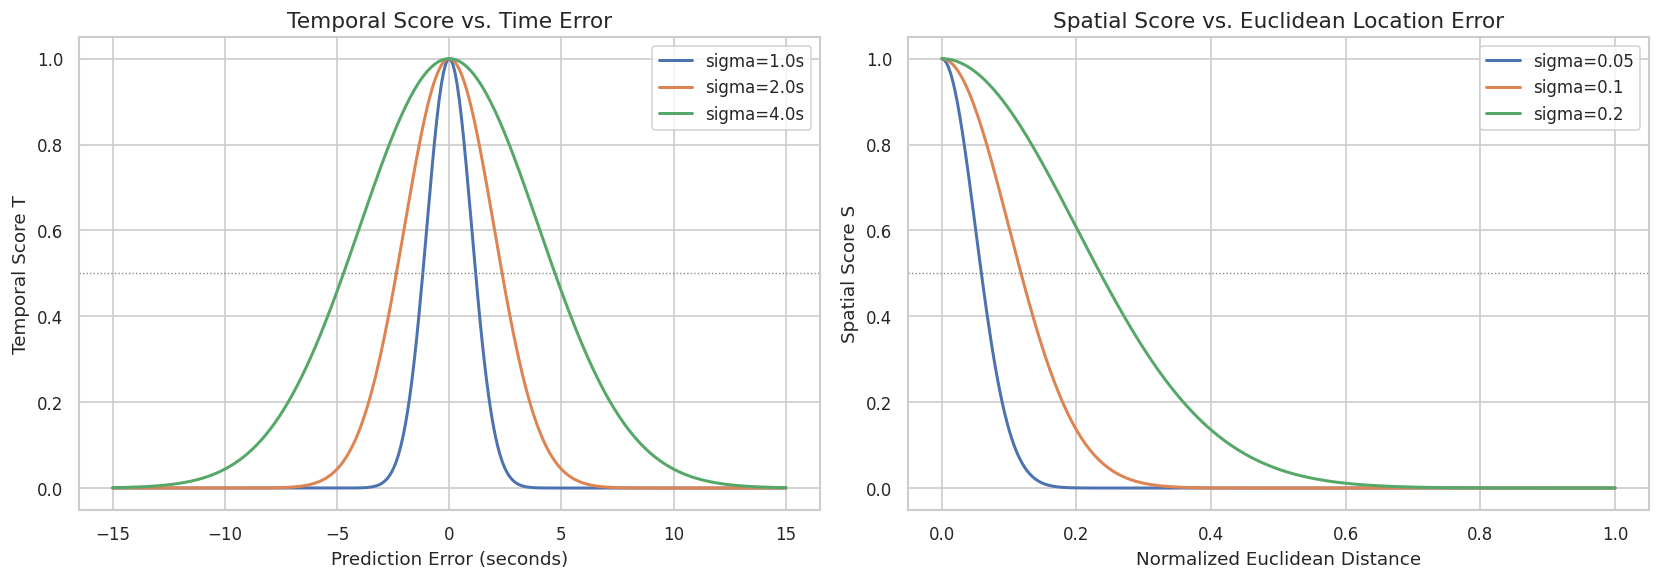

In [50]:
# [EVAL] Score sensitivity analysis -- visualize Gaussian scoring curves

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Temporal score curve
time_errors = np.linspace(-15, 15, 300)  # seconds from ground truth
for sigma in [1.0, 2.0, 4.0]:
    t_scores = np.exp(-0.5 * (time_errors / sigma) ** 2)
    axes[0].plot(time_errors, t_scores, label=f'sigma={sigma}s', linewidth=1.8)

axes[0].set_title('Temporal Score vs. Time Error', fontsize=13)
axes[0].set_xlabel('Prediction Error (seconds)', fontsize=11)
axes[0].set_ylabel('Temporal Score T', fontsize=11)
axes[0].legend()
axes[0].axhline(0.5, linestyle=':', color='grey', linewidth=0.8)

# Spatial score curve (radial)
dist_errors = np.linspace(0, 1.0, 300)  # normalized Euclidean distance
for sigma in [0.05, 0.10, 0.20]:
    s_scores = np.exp(-0.5 * (dist_errors / sigma) ** 2)
    axes[1].plot(dist_errors, s_scores, label=f'sigma={sigma}', linewidth=1.8)

axes[1].set_title('Spatial Score vs. Euclidean Location Error', fontsize=13)
axes[1].set_xlabel('Normalized Euclidean Distance', fontsize=11)
axes[1].set_ylabel('Spatial Score S', fontsize=11)
axes[1].legend()
axes[1].axhline(0.5, linestyle=':', color='grey', linewidth=0.8)

plt.tight_layout()
plt.show()

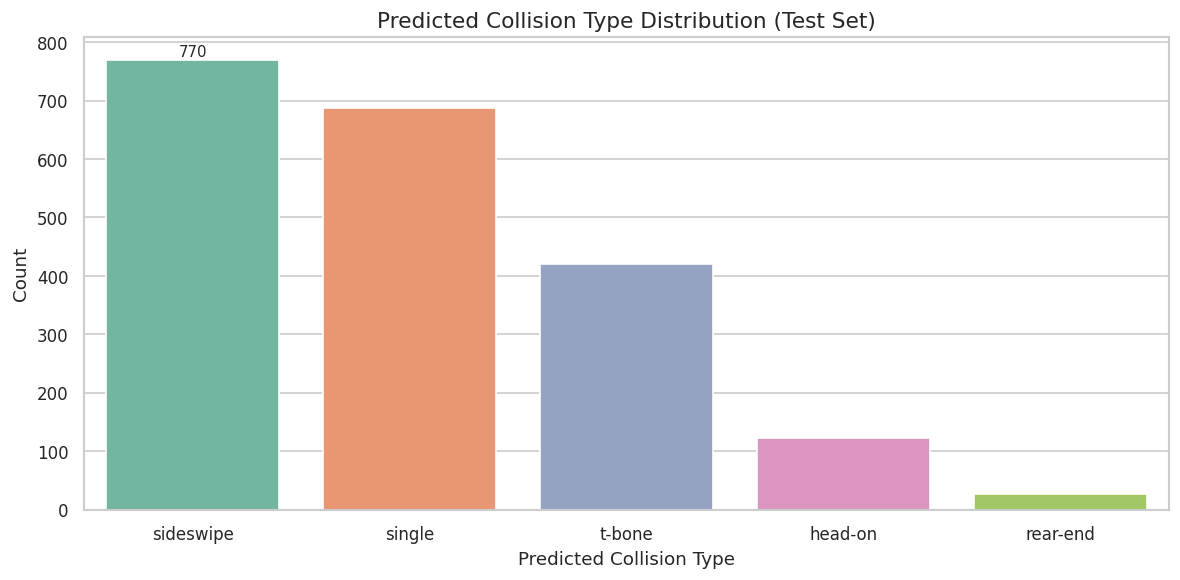

In [51]:
# [EVAL] Predicted collision type distribution for submission
if not submission_df.empty and 'type' in submission_df.columns:
    pred_type_dist = submission_df['type'].value_counts().reset_index()
    pred_type_dist.columns = ['collision_type', 'count']

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(
        data=pred_type_dist,
        x='collision_type', y='count',
        palette='Set2', ax=ax
    )
    ax.set_title('Predicted Collision Type Distribution (Test Set)', fontsize=13)
    ax.set_xlabel('Predicted Collision Type', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.bar_label(ax.containers[0], fontsize=9)
    plt.tight_layout()
    plt.show()

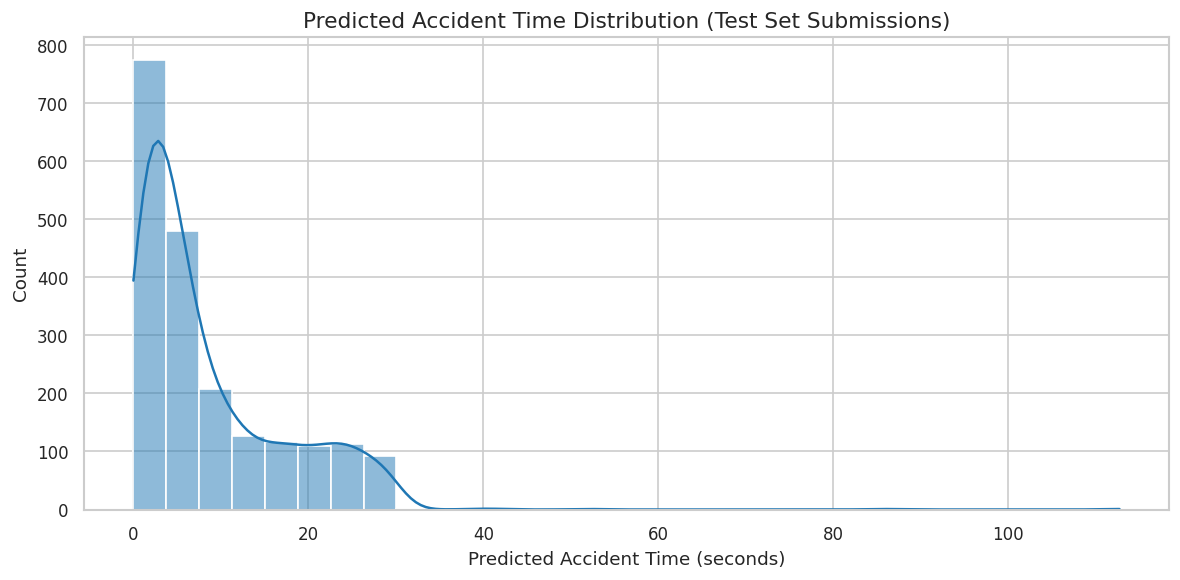

In [52]:
# [EVAL] Predicted accident time distribution for submission
if not submission_df.empty and 'accident_time' in submission_df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.histplot(submission_df['accident_time'], bins=30, kde=True,
                 color=PALETTE['primary'], ax=ax)
    ax.set_title('Predicted Accident Time Distribution (Test Set Submissions)', fontsize=13)
    ax.set_xlabel('Predicted Accident Time (seconds)', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    plt.tight_layout()
    plt.show()

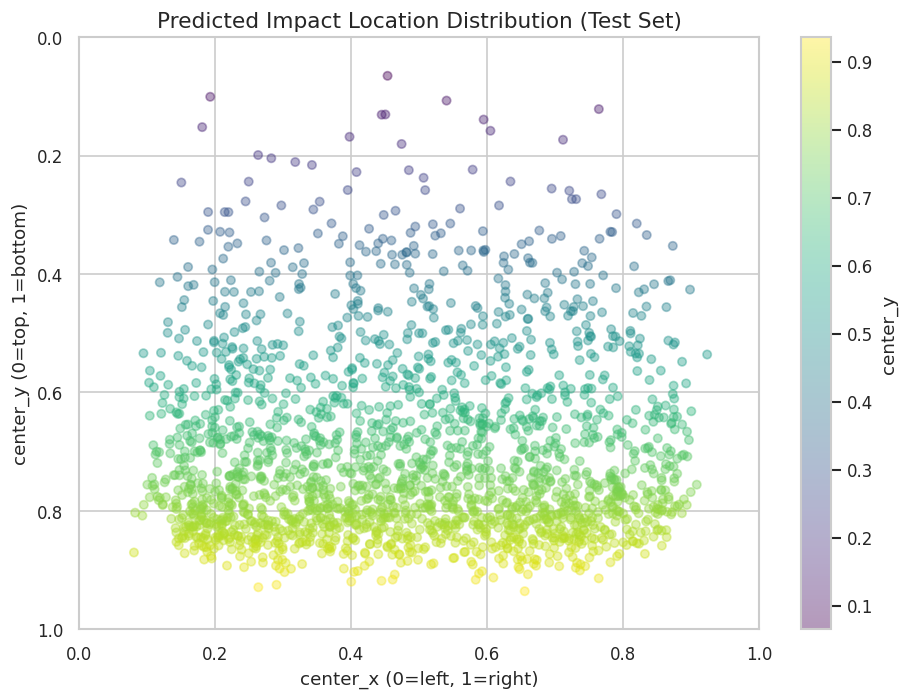

In [53]:
# [EVAL] Predicted impact location scatter for test set
if not submission_df.empty and all(c in submission_df.columns for c in ['center_x', 'center_y']):
    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(
        submission_df['center_x'],
        submission_df['center_y'],
        alpha=0.4, s=25, c=submission_df['center_y'],
        cmap='viridis'
    )
    plt.colorbar(scatter, ax=ax, label='center_y')
    ax.set_title('Predicted Impact Location Distribution (Test Set)', fontsize=13)
    ax.set_xlabel('center_x (0=left, 1=right)', fontsize=11)
    ax.set_ylabel('center_y (0=top, 1=bottom)', fontsize=11)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

---
## 8. Conclusion

**Technical findings and pipeline observations:**

- The frame-difference z-score series reliably identifies sharp motion events in synthetic CCTV clips; applicability to real CCTV footage depends on compression artifact levels and baseline motion from non-accident traffic.
- Optical-flow weighted centroid provides a geometry-consistent spatial prediction, but degrades in wide-angle scenes where motion from non-colliding background vehicles produces competing high-magnitude regions.
- CLIP zero-shot classification benefits from multi-frame mean-pooling of visual features near the predicted accident time, reducing single-frame noise from motion blur during impact.
- The harmonic mean metric is sensitive to classification accuracy: a zero classification score drives the entire final score to 0, making collision-type precision disproportionately important relative to small temporal or spatial errors.
- Prompt engineering for CLIP text embeddings is non-trivial: prompts anchored to observable visual evidence (vehicle orientation, trajectory, frame geometry) outperform prompts referencing collision mechanics.
- The absence of a real labeled training split eliminates dataset-specific fine-tuning as a viable approach; robustness to CCTV compression, varying FPS, and resolution differences is the primary engineering constraint.
- Synthetic-to-real domain gap is the central challenge: CARLA-rendered scenes have clean geometry and consistent lighting, whereas real feeds exhibit codec artifacts, lens distortion, and uncontrolled illumination.
- Z-score threshold tuning on the synthetic calibration set is likely to be suboptimal for real footage; adaptive per-video thresholding (e.g., based on local baseline motion statistics) is a productive extension.

---
## 9. References

1. **Competition:** [ACCIDENT @ CVPR 2026 -- Kaggle](https://kaggle.com/competitions/accident)

2. **Workshop:** [AUTOPILOT @ CVPR 2026](https://autopilot-workshop.github.io)

3. **CLIP:** Radford, A. et al. "Learning Transferable Visual Models From Natural Language Supervision." ICML 2021. [arXiv:2103.00020](https://arxiv.org/abs/2103.00020)

4. **Optical Flow (Farneback):** Farneback, G. "Two-Frame Motion Estimation Based on Polynomial Expansion." SCIA 2003. [Springer](https://link.springer.com/chapter/10.1007/3-540-45103-X_50)

5. **CARLA Simulator:** Dosovitskiy, A. et al. "CARLA: An Open Urban Driving Simulator." CoRL 2017. [arXiv:1711.03938](https://arxiv.org/abs/1711.03938)

6. **OpenCV Documentation:** [https://docs.opencv.org](https://docs.opencv.org)

7. **OpenAI CLIP Repository:** [https://github.com/openai/CLIP](https://github.com/openai/CLIP)

8. **Traffic accident video datasets survey:** Bouzid, Y. et al. "Anomaly Detection in Traffic Surveillance Videos: A Survey." Sensors 2022.